# 5주차 실습 — 단어 표현, 텍스트 분류, 그리고 텍스트 유사도

**자연어처리 | Chapter 5 실습 노트북**

---

### 이번 실습의 목표

강의에서 다룬 세 주제를 **외부 라이브러리 없이 직접 구현**해 보고, 앞 단계의 출력이 다음 단계의 입력이 되는 과정을 눈으로 확인한다.

| PART | 주제 | 대응 절 | 주요 도구 |
|:---:|---|:---:|---|
| 1 | 단어 표현 (원-핫 · BoW · N-gram · TF-IDF) | 5.1 | `numpy`, `pandas` |
| 2 | 텍스트 분류 (EDA → 벡터화 → 학습 → 평가) | 5.2 | `numpy`, `matplotlib` |
| 3 | 텍스트 유사도 (자카드 · 코사인 · 유클리디언 · 맨해튼) | 5.3 | `numpy` |
| 4 | 과제 5문항 (자동 채점 셀 포함, 각 20점 / 총 100점) | — | 위 전부 |

### 진행 방법

1. 아래 **[0] 환경 설정** 셀을 먼저 실행한다. (Colab 기준 30초 이내)
2. 위에서부터 순서대로 셀을 실행한다.
3. 각 PART 끝의 **✅ 자가 검증** 셀이 모두 `통과` 로 나오는지 확인한다.
4. 노트북 맨 끝의 **[과제] 5문항** 이 제출 대상이다. 문항마다 **자동 채점 셀** 이 붙어 있다.

> **실행 환경** : Google Colab 권장. 로컬 주피터에서도 동일하게 동작한다.
> `scikit-learn` 이 없어도 실습과 과제는 **모두 정상 동작** 한다. (비교용 셀만 자동으로 건너뛴다)

> **[문제] 노트북 사용법**
>
> - `raise NotImplementedError(...)` 로 막혀 있는 부분이 여러분이 채워야 할 곳이다.
>   그 줄을 지우고 직접 코드를 작성한다.
> - 아직 구현하지 않은 과제가 있어도 `런타임 → 모두 실행` 은 끝까지 동작한다.
>   미구현 과제가 있는 셀은 `▶ 미구현 : ...` 이라고만 출력된다.
> - 각 과제 아래의 **채점 셀** 이 통과(`통과!` 출력)해야 정답으로 인정된다.


## [0] 환경 설정

이번 실습에서 사용하는 라이브러리는 다음과 같다.

- **NumPy** — 행렬 연산. DTM · TF-IDF · 모델 학습을 전부 numpy 로 직접 구현한다. &nbsp;→ *Colab에 이미 설치되어 있다*
- **pandas** — 코퍼스와 결과 표를 보기 좋게 정리 &nbsp;→ *Colab에 이미 설치되어 있다*
- **matplotlib** — 길이 분포·빈도 그래프. 한글이 깨지지 않도록 나눔 폰트를 설치한다.
- **scikit-learn** — **선택** 사항. 직접 만든 TF-IDF · 유사도 결과가 맞는지 대조하는 용도로만 쓴다. 없으면 해당 셀만 건너뛴다.

> **중요** : `pip install numpy pandas` 처럼 이미 설치된 패키지를 **다시 설치하면 안 된다.**
> 의존 패키지가 교체되면서 "런타임을 다시 시작하라"는 안내가 뜨고,
> 재시작하면 앞에서 만들어 둔 변수(`df`, `vocab`, `DTM` 등)가 모두 사라져 처음부터 다시 실행해야 한다.
> 그래서 아래 셀에서는 **Colab 에 없는 한글 폰트만** 설치한다.

아래 두 셀은 한 번만 실행하면 된다.


In [106]:
# ── [0-1] 라이브러리 설치 (로컬 VS Code 기준) ──────────────────────
# 원본은 Colab 기준(!apt-get 으로 나눔 폰트 설치)이라 Windows 에서는 동작하지 않는다.
# numpy · pandas · matplotlib · scikit-learn 은 이미 설치되어 있고,
# 한글 폰트는 [0-2] 셀에서 Windows 기본 '맑은 고딕'으로 자동 설정되므로 따로 설치할 것이 없다.
print("설치 완료")


설치 완료


In [107]:
# ── [0-2] 공통 import 및 한글 폰트 설정 ───────────────────────────
import re
import math
import random
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')          # 경고 메시지 숨김 (결과 확인을 쉽게 하기 위함)

np.set_printoptions(precision=3, suppress=True, linewidth=120)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)
random.seed(42)                            # 실행할 때마다 같은 결과가 나오도록 난수 고정
np.random.seed(42)

# 한글 폰트 설정 ---------------------------------------------------------
# 주의 : apt 로 폰트를 설치해도 matplotlib 의 폰트 캐시는 갱신되지 않기 때문에
#        plt.rcParams['font.family'] 만 바꾸면 그래프의 한글이 그대로 깨진다.
#        addfont() 로 폰트 파일을 직접 등록해야 재시작 없이 즉시 적용된다.
import os
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

NANUM = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
if os.path.exists(NANUM):
    fm.fontManager.addfont(NANUM)                 # 폰트 캐시를 다시 만들지 않고 등록
    plt.rcParams['font.family'] = 'NanumGothic'
else:                                             # 로컬(윈도우/맥) 환경 대비
    for cand in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR']:
        if any(f.name == cand for f in fm.fontManager.ttflist):
            plt.rcParams['font.family'] = cand
            break
plt.rcParams['axes.unicode_minus'] = False        # 마이너스 기호 깨짐 방지
HAS_PLT = True

# 선택 라이브러리 확인 (없어도 실습과 과제는 모두 정상 동작한다)
try:
    import sklearn
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False

# 주피터/코랩이 아닌 환경에서도 display() 가 동작하도록 대비
try:
    display
except NameError:
    def display(x):
        print(x)

print('numpy                :', np.__version__)
print('pandas               :', pd.__version__)
print('matplotlib 한글 폰트 :', plt.rcParams['font.family'])
print('scikit-learn 사용 가능 :', HAS_SKLEARN)


numpy                : 2.3.1
pandas               : 2.3.1
matplotlib 한글 폰트 : ['Malgun Gothic']
scikit-learn 사용 가능 : True


---
# 데이터 : 한국어 영화 리뷰 코퍼스 (내장)

외부 다운로드 없이 실습할 수 있도록 **영화 리뷰 200건**을 노트북에 내장했습니다.

- `label = 1` : 긍정 리뷰 (100건)
- `label = 0` : 부정 리뷰 (100건)

실제 연구에서는 NSMC(네이버 영화 리뷰, 20만 건)나 IMDB(5만 건) 같은 대규모 코퍼스를 사용하지만,
원리를 이해하는 데에는 작은 코퍼스가 오히려 유리합니다. 행렬을 눈으로 직접 확인할 수 있기 때문입니다.

In [108]:
# ===== 내장 코퍼스 : 긍정 리뷰 100건 =====
POS = [
    "이 영화 정말 재미있고 배우 연기가 훌륭하다",
    "스토리가 탄탄하고 연출이 아주 좋았다",
    "올해 본 영화 중에 가장 감동적인 작품이다",
    "음악이 아름답고 영상미가 뛰어나다",
    "배우 연기가 자연스러워서 몰입이 잘 되었다",
    "가족과 함께 보기에 아주 좋은 영화다",
    "결말이 인상적이고 여운이 오래 남는다",
    "시간 가는 줄 모르고 재미있게 보았다",
    "각본이 훌륭하고 대사가 인상 깊다",
    "촬영이 아름답고 색감이 정말 좋다",
    "감독의 연출력이 돋보이는 수작이다",
    "주인공의 성장 과정이 감동적이다",
    "유머 감각이 뛰어나서 계속 웃었다",
    "예상하지 못한 반전이 아주 신선하다",
    "배경 음악이 장면과 완벽하게 어울린다",
    "다시 보고 싶은 마음이 드는 영화다",
    "친구에게 꼭 추천하고 싶은 작품이다",
    "메시지가 분명하고 울림이 크다",
    "캐릭터 하나하나가 매력적이다",
    "연기와 연출 모두 훌륭한 작품이다",
    "몰입감이 뛰어나서 지루할 틈이 없다",
    "따뜻한 이야기라서 기분이 좋아졌다",
    "영상미가 최고이고 음악도 훌륭하다",
    "탄탄한 각본 덕분에 끝까지 재미있다",
    "생각할 거리를 주는 좋은 영화다",
    "액션 장면이 박진감 넘치고 시원하다",
    "잔잔하지만 깊은 여운을 남긴다",
    "배우들의 호흡이 정말 좋다",
    "완성도가 높은 작품이라 만족스럽다",
    "기대 이상으로 훌륭한 영화였다",
    "가슴이 뭉클해지는 감동적인 장면이 많다",
    "연출이 세련되고 편집이 깔끔하다",
    "아이와 함께 즐겁게 관람했다",
    "원작보다 더 좋았던 각색이다",
    "마지막 장면이 오래 기억에 남는다",
    "웃음과 눈물이 적절하게 섞여 있다",
    "신인 배우의 연기가 아주 인상적이다",
    "시나리오가 촘촘해서 빈틈이 없다",
    "볼수록 매력이 느껴지는 영화다",
    "분위기가 좋아서 계속 보고 싶다",
    "주제 의식이 뚜렷하고 훌륭하다",
    "구성이 참신하고 전개가 빠르다",
    "감정선이 섬세하게 잘 표현되었다",
    "미술과 의상이 아주 아름답다",
    "대사가 유쾌하고 재치가 넘친다",
    "긴장감이 끝까지 유지되어 좋았다",
    "전개가 흥미로워서 몰입이 잘 된다",
    "따뜻하고 희망적인 결말이 좋다",
    "몇 번을 봐도 재미있는 명작이다",
    "배우의 표정 연기가 압도적이다",
    "음향 효과가 실감 나고 훌륭하다",
    "이야기의 짜임새가 아주 좋다",
    "잔잔한 감동이 오래 남는 영화다",
    "연출과 음악의 조화가 완벽하다",
    "캐릭터의 매력이 잘 살아 있다",
    "예술적인 완성도가 아주 높다",
    "보고 나서 기분이 좋아지는 작품이다",
    "액션과 드라마의 균형이 훌륭하다",
    "인물의 심리 묘사가 탁월하다",
    "올해 최고의 작품이라 추천한다",
    "영상미가 인상적이다",
    "촬영이 매우 만족스럽다",
    "배우 연기가 훌륭하다",
    "전개가 인상적이다",
    "전개가 자연스럽다",
    "캐릭터가 정말 좋다",
    "스토리가 인상적이다",
    "대사가 자연스럽다",
    "영상미가 아주 뛰어나다",
    "전개가 신선하다",
    "구성이 아주 뛰어나다",
    "스토리가 훌륭하다",
    "분위기가 자연스럽다",
    "각본이 정말 좋다",
    "촬영이 훌륭하다",
    "전개가 매우 만족스럽다",
    "분위기가 인상적이다",
    "편집이 훌륭하다",
    "대사가 정말 좋다",
    "스토리가 정말 좋다",
    "음악이 매력적이다",
    "편집이 매우 만족스럽다",
    "각본이 인상적이다",
    "결말이 훌륭하다",
    "액션이 아주 뛰어나다",
    "구성이 정말 좋다",
    "대사가 신선하다",
    "캐릭터가 인상적이다",
    "연출이 자연스럽다",
    "음악이 정말 좋다",
    "전개가 매력적이다",
    "결말이 정말 좋다",
    "배우 연기가 자연스럽다",
    "캐릭터가 아주 뛰어나다",
    "배우 연기가 매우 만족스럽다",
    "각본이 매력적이다",
    "스토리가 아주 뛰어나다",
    "각본이 아주 뛰어나다",
    "편집이 인상적이다",
    "연기력이 자연스럽다",
]

print(len(POS), "건")
print(POS[:3])

100 건
['이 영화 정말 재미있고 배우 연기가 훌륭하다', '스토리가 탄탄하고 연출이 아주 좋았다', '올해 본 영화 중에 가장 감동적인 작품이다']


In [109]:
# ===== 내장 코퍼스 : 부정 리뷰 100건 =====
NEG = [
    "스토리가 지루하고 전개가 너무 느리다",
    "연기가 어색해서 몰입이 전혀 안 된다",
    "시간이 아까운 최악의 영화였다",
    "결말이 허무하고 실망스럽다",
    "각본이 엉성하고 개연성이 없다",
    "돈이 아까워서 후회했다",
    "배우 연기가 부자연스럽고 발음이 나쁘다",
    "너무 뻔한 전개라서 재미없다",
    "편집이 산만하고 정신이 없다",
    "음악이 장면과 전혀 어울리지 않는다",
    "캐릭터가 매력이 없고 밋밋하다",
    "지루해서 중간에 졸았다",
    "감독의 연출이 아쉽고 어수선하다",
    "억지 감동을 강요해서 불편하다",
    "대사가 유치하고 어색하다",
    "설정이 이상하고 납득이 안 된다",
    "긴장감이 전혀 없어서 지루하다",
    "예고편이 훨씬 재미있었다",
    "이야기가 산만해서 이해하기 어렵다",
    "특수 효과가 조잡하고 어설프다",
    "주인공의 행동이 이해되지 않는다",
    "원작을 망친 최악의 각색이다",
    "너무 길어서 지치고 피곤하다",
    "웃음 포인트가 하나도 없다",
    "감정선이 뚝뚝 끊겨서 몰입이 안 된다",
    "결말이 급하게 마무리되어 아쉽다",
    "배우들의 호흡이 전혀 맞지 않는다",
    "촬영이 어둡고 답답하다",
    "기대에 한참 못 미치는 영화다",
    "내용이 빈약하고 알맹이가 없다",
    "억지 설정이 너무 많아서 불편하다",
    "전개가 예측 가능해서 시시하다",
    "캐릭터 설명이 부족해서 공감이 안 된다",
    "액션 장면이 어색하고 촌스럽다",
    "음향이 답답하고 대사가 안 들린다",
    "주제가 불분명해서 혼란스럽다",
    "지나친 신파라서 거부감이 든다",
    "다시는 보고 싶지 않은 영화다",
    "구성이 엉망이라 집중이 안 된다",
    "연출이 낡고 촌스럽게 느껴진다",
    "유머가 억지스럽고 재미없다",
    "인물의 감정 변화가 갑작스럽다",
    "전혀 추천하고 싶지 않은 작품이다",
    "완성도가 낮아서 실망이 크다",
    "장면 전환이 어색하고 부자연스럽다",
    "내용이 반복되어 지루하기만 하다",
    "돈과 시간을 모두 낭비한 느낌이다",
    "배우가 아깝다는 생각만 들었다",
    "대사 전달력이 떨어져서 답답하다",
    "이야기가 억지스럽고 유치하다",
    "긴장감 없이 늘어지기만 한다",
    "감동도 재미도 없는 실패작이다",
    "설득력이 부족해서 몰입이 깨진다",
    "지루한 장면이 너무 자주 반복된다",
    "결말이 이해되지 않아 답답하다",
    "촬영과 편집 모두 조잡하다",
    "기대만큼 못한 실망스러운 작품이다",
    "캐릭터가 전형적이고 지루하다",
    "각본이 부실해서 몰입이 어렵다",
    "최악의 연출과 최악의 각본이다",
    "음악이 정말 실망스럽다",
    "촬영이 매우 아쉽다",
    "구성이 매우 아쉽다",
    "캐릭터가 지루하다",
    "연기력이 형편없다",
    "연출이 매우 아쉽다",
    "각본이 아주 어색하다",
    "스토리가 아주 어색하다",
    "음악이 형편없다",
    "캐릭터가 아주 어색하다",
    "구성이 형편없다",
    "촬영이 정말 실망스럽다",
    "연기력이 매우 아쉽다",
    "편집이 정말 실망스럽다",
    "음악이 매우 아쉽다",
    "영상미가 촌스럽다",
    "촬영이 뻔하다",
    "전개가 정말 실망스럽다",
    "연출이 형편없다",
    "대사가 산만하다",
    "편집이 산만하다",
    "대사가 촌스럽다",
    "각본이 매우 아쉽다",
    "영상미가 지루하다",
    "각본이 형편없다",
    "연출이 뻔하다",
    "캐릭터가 형편없다",
    "연기력이 지루하다",
    "액션이 산만하다",
    "각본이 정말 실망스럽다",
    "결말이 매우 아쉽다",
    "각본이 산만하다",
    "스토리가 촌스럽다",
    "액션이 매우 아쉽다",
    "구성이 지루하다",
    "분위기가 형편없다",
    "액션이 정말 실망스럽다",
    "음악이 뻔하다",
    "분위기가 정말 실망스럽다",
    "캐릭터가 촌스럽다",
]

print(len(NEG), "건")
print(NEG[:3])

100 건
['스토리가 지루하고 전개가 너무 느리다', '연기가 어색해서 몰입이 전혀 안 된다', '시간이 아까운 최악의 영화였다']


In [110]:
# ===== 데이터프레임으로 정리 =====
df = pd.DataFrame({
    'text':  POS + NEG,
    'label': [1] * len(POS) + [0] * len(NEG),
})
# 순서를 섞음 (긍정/부정이 뭉쳐 있으면 학습에 불리)
df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print('전체 데이터 수 :', len(df))
print(df['label'].value_counts().rename({1: '긍정', 0: '부정'}))
df.head(8)

전체 데이터 수 : 200
label
긍정    100
부정    100
Name: count, dtype: int64


,text,label
0,각본이 매력적이다,1
1,다시 보고 싶은 마음이 드는 영화다,1
2,가슴이 뭉클해지는 감동적인 장면이 많다,1
3,각본이 부실해서 몰입이 어렵다,0
4,기대에 한참 못 미치는 영화다,0
5,설정이 이상하고 납득이 안 된다,0
6,전개가 신선하다,1
7,구성이 형편없다,0


---
---
# Part 1. 단어 표현 (Word Representation)

> **핵심 질문** : 컴퓨터가 이해할 수 있도록 단어와 문서를 어떻게 숫자로 바꿀 것인가?

## 1-1. 토큰화 (Tokenization)

문서를 벡터로 만들려면 먼저 **의미 단위(토큰)로 쪼개야** 합니다.

영어는 공백으로 나누면 대체로 단어가 되지만, 한국어는 **교착어**라서 그렇지 않습니다.

```
"영화가", "영화를", "영화는"  →  공백 기준으로 나누면 모두 다른 토큰!
```

제대로 하려면 `KoNLPy`, `Kiwi` 같은 형태소 분석기가 필요하지만 설치가 무겁기 때문에,
이 실습에서는 **간이 토크나이저**를 직접 만들어 사용합니다. 세 단계로 구성됩니다.

| 단계 | 하는 일 | 예시 |
|---|---|---|
| ① 정제 | 소문자화, 특수문자 제거 | `"재미있고, 훌륭하다!"` → `"재미있고 훌륭하다"` |
| ② 조사 분리 | 어절 끝의 조사를 떼어냄 | `"영화가"` → `"영화" + "가"` |
| ③ 어간 추출 | 어미를 떼어 형태를 통일 | `"재미있고" / "재미있다" / "재미있게"` → 모두 `"재미있"` |

③번 어간 추출이 없으면 `재미있고`, `재미있다`, `재미있게`가 **전부 다른 단어**로 취급되어
어휘 사전만 커지고 학습은 잘 되지 않습니다. 직접 확인해 보겠습니다.

In [111]:
# ===== 1-1. 간이 한국어 토크나이저 =====

# 분리 대상 조사 (긴 것부터 검사해야 올바르게 분리됨)
JOSA = ['에서는', '에게서', '으로는', '이라서', '에서', '에게', '으로', '까지', '부터',
        '이나', '라서', '보다', '처럼', '만큼', '조차', '마저', '이란',
        '은', '는', '이', '가', '을', '를', '에', '의', '도', '와', '과', '로', '만']

# 어간 추출 시 떼어낼 어미
#  - 두 글자 이상 어미는 어간이 1글자만 남아도 제거   (예: 좋았다 → 좋)
#  - 한 글자 어미는 어간이 2글자 이상 남을 때만 제거  (예: 최고 → 최고, 잘못 자르지 않음)
ENDINGS_MULTI = ['스럽습니다', '스럽다', '스러운', '습니다', '했었다', '하였다', '했다',
                 '한다', '된다', '진다', '였다', '았다', '었다', '이다', '하다', '하고',
                 '하게', '해서', '라서', '하는', '되는', '이고', '스런']
ENDINGS_SINGLE = ['다', '고', '게', '한', '인', '된', '며', '서', '지']

RE_MULTI = re.compile('(' + '|'.join(sorted(ENDINGS_MULTI, key=len, reverse=True)) + ')$')
RE_SINGLE = re.compile('(' + '|'.join(ENDINGS_SINGLE) + ')$')


def clean_text(text):
    """① 정제 : 소문자화 + 한글/영문/숫자/공백만 남기고 제거"""
    text = text.lower()
    text = re.sub(r'[^가-힣a-z0-9\s]', ' ', text)   # 특수문자 → 공백
    text = re.sub(r'\s+', ' ', text).strip()        # 연속 공백 정리
    return text


def stem(word):
    """③ 어간 추출 : 어미를 최대 2번까지 떼어냄"""
    for _ in range(2):
        m = RE_MULTI.search(word)
        if m and m.start() >= 1:
            word = word[:m.start()]
            continue
        m = RE_SINGLE.search(word)
        if m and m.start() >= 2:
            word = word[:m.start()]
            continue
        break
    return word


def tokenize(text, use_stem=True):
    """② 조사 분리 + ③ 어간 추출"""
    tokens = []
    for word in clean_text(text).split():
        for j in sorted(JOSA, key=len, reverse=True):
            # 조사를 뗀 나머지가 2글자 이상일 때만 분리 (과분할 방지)
            if word.endswith(j) and len(word) - len(j) >= 2:
                tokens.append(stem(word[:-len(j)]) if use_stem else word[:-len(j)])
                tokens.append(j)
                break
        else:
            tokens.append(stem(word) if use_stem else word)
    return [t for t in tokens if t]


# 동작 확인
sample = "이 영화 정말 재미있고, 배우 연기가 훌륭하다!"
print('원문        :', sample)
print('① 정제      :', clean_text(sample))
print('② 조사 분리 :', tokenize(sample, use_stem=False))
print('③ 어간 추출 :', tokenize(sample))

print()
print('어간 추출의 효과 :')
for w in ['재미있고', '재미있다', '재미있게', '훌륭하다', '훌륭한', '지루하고', '지루하다',
          '최고', '주인']:
    print(f'  {w:>5s} → {stem(w)}')
print('  ↑ "최고", "주인" 처럼 어간이 1글자만 남는 경우는 자르지 않습니다.')

원문        : 이 영화 정말 재미있고, 배우 연기가 훌륭하다!
① 정제      : 이 영화 정말 재미있고 배우 연기가 훌륭하다
② 조사 분리 : ['이', '영화', '정말', '재미있고', '배우', '연기', '가', '훌륭하다']
③ 어간 추출 : ['이', '영화', '정말', '재미있', '배우', '연기', '가', '훌륭']

어간 추출의 효과 :
   재미있고 → 재미있
   재미있다 → 재미있
   재미있게 → 재미있
   훌륭하다 → 훌륭
    훌륭한 → 훌륭
   지루하고 → 지루
   지루하다 → 지루
     최고 → 최고
     주인 → 주인
  ↑ "최고", "주인" 처럼 어간이 1글자만 남는 경우는 자르지 않습니다.


In [112]:
# ===== 전체 코퍼스 토큰화 =====
df['tokens'] = df['text'].apply(tokenize)

print('예시 3건')
for t, tk in zip(df['text'][:3], df['tokens'][:3]):
    print(f'  {t}\n   → {tk}')

all_tokens = [t for toks in df['tokens'] for t in toks]
no_stem = [t for txt in df['text'] for t in tokenize(txt, use_stem=False)]
print('\n전체 토큰 수 :', len(all_tokens))
print('서로 다른 토큰 수 — 어간 추출 O : {:4d}'.format(len(set(all_tokens))))
print('서로 다른 토큰 수 — 어간 추출 X : {:4d}   ← 어간 추출로 사전이 줄어듦'.format(len(set(no_stem))))
print('가장 많이 등장한 토큰 10개 :', Counter(all_tokens).most_common(10))

예시 3건
  각본이 매력적이다
   → ['각본', '이', '매력적']
  다시 보고 싶은 마음이 드는 영화다
   → ['다시', '보고', '싶은', '마음', '이', '드는', '영화']
  가슴이 뭉클해지는 감동적인 장면이 많다
   → ['가슴', '이', '뭉클해', '는', '감동적', '장면', '이', '많다']

전체 토큰 수 : 987
서로 다른 토큰 수 — 어간 추출 O :  322
서로 다른 토큰 수 — 어간 추출 X :  357   ← 어간 추출로 사전이 줄어듦
가장 많이 등장한 토큰 10개 : [('이', 125), ('가', 76), ('의', 19), ('정말', 17), ('아주', 16), ('각본', 14), ('훌륭', 13), ('매우', 12), ('캐릭터', 12), ('영화', 11)]


## 1-2. 어휘 사전과 원-핫 인코딩 (One-hot Encoding)

**어휘 사전(Vocabulary)** : 모든 단어에 고유한 정수 인덱스를 부여한 사전

**원-핫 벡터** : 어휘 사전 크기 `V`의 벡터에서 자기 인덱스만 `1`, 나머지는 모두 `0`

$$\text{one-hot}(w_i) = [\,0,\ \dots,\ \underbrace{1}_{i\text{번째}},\ \dots,\ 0\,] \in \mathbb{R}^{V}$$

In [113]:
# ===== 1-2. 어휘 사전 구축 =====
def build_vocab(token_lists, min_count=1):
    """등장 횟수가 min_count 이상인 토큰으로 어휘 사전 생성"""
    counter = Counter(t for toks in token_lists for t in toks)
    words = sorted([w for w, c in counter.items() if c >= min_count])
    return {w: i for i, w in enumerate(words)}

vocab = build_vocab(df['tokens'])
inv_vocab = {i: w for w, i in vocab.items()}
V = len(vocab)
print('어휘 사전 크기 V =', V)
print('일부 예시 :', dict(list(vocab.items())[:8]))

어휘 사전 크기 V = 322
일부 예시 : {'가': 0, '가는': 1, '가능': 2, '가슴': 3, '가장': 4, '가족': 5, '각본': 6, '각색': 7}


In [114]:
# ===== 원-핫 인코딩 =====
def one_hot(word, vocab):
    vec = np.zeros(len(vocab), dtype=int)
    if word in vocab:
        vec[vocab[word]] = 1
    return vec

# vocab 은 어간 추출을 거친 토큰으로 만들어졌으므로 '재미있고' 같은 원형은 사전에 없다
for w in ['영화', '재미있', '지루']:
    v = one_hot(w, vocab)
    print(f'{w:>6s} → 인덱스 {vocab.get(w, -1):4d}, 벡터 길이 {len(v)}, 1의 개수 {v.sum()}')

# 원-핫의 한계 ① : 어떤 두 단어를 골라도 내적(유사도)이 항상 0
# 두 단어 모두 어휘 사전에 존재하는 단어여야 '직교성'을 제대로 보일 수 있다.
a, b = one_hot('영화', vocab), one_hot('작품', vocab)
print('\n"영화" · "작품" 내적 =', int(a @ b), '  ← 의미가 비슷해도 항상 0!')

# 원-핫의 한계 ② : 희소성 (거의 전부 0)
print(f'벡터 하나의 0 비율 = {(V - 1) / V:.3%}')
print(f'전체 어휘를 원-핫으로 저장하면 {V} x {V} = {V * V:,} 개의 값이 필요')

    영화 → 인덱스  207, 벡터 길이 322, 1의 개수 1
   재미있 → 인덱스  252, 벡터 길이 322, 1의 개수 1
    지루 → 인덱스  279, 벡터 길이 322, 1의 개수 1

"영화" · "작품" 내적 = 0   ← 의미가 비슷해도 항상 0!
벡터 하나의 0 비율 = 99.689%
전체 어휘를 원-핫으로 저장하면 322 x 322 = 103,684 개의 값이 필요


## 1-3. Bag of Words (BoW) 와 문서 단어 행렬 (DTM)

**BoW** : 단어의 **순서는 버리고 등장 횟수만** 세는 문서 표현

**DTM** : 각 문서의 BoW 벡터를 행으로 쌓은 행렬 (행 = 문서, 열 = 단어)

In [115]:
# ===== 1-3. BoW / DTM 직접 구현 =====
def build_dtm(token_lists, vocab):
    """문서 단어 행렬 (n_docs x V) 생성"""
    dtm = np.zeros((len(token_lists), len(vocab)), dtype=np.float64)
    for i, toks in enumerate(token_lists):
        for t in toks:
            if t in vocab:
                dtm[i, vocab[t]] += 1
    return dtm

# 강의 슬라이드의 미니 예제로 먼저 확인
mini_docs = ["영화 재미 영화", "영화 지루", "재미 재미 추천"]
mini_tokens = [d.split() for d in mini_docs]
mini_vocab = build_vocab(mini_tokens)
mini_dtm = build_dtm(mini_tokens, mini_vocab)

print('어휘 사전 :', mini_vocab)
display(pd.DataFrame(mini_dtm.astype(int),
                     index=['D1', 'D2', 'D3'],
                     columns=list(mini_vocab.keys())))

어휘 사전 : {'영화': 0, '재미': 1, '지루': 2, '추천': 3}


,영화,재미,지루,추천
D1,2,1,0,0
D2,1,0,1,0
D3,0,2,0,1


In [116]:
# ===== 실제 코퍼스의 DTM =====
DTM = build_dtm(df['tokens'], vocab)
print('DTM 크기 :', DTM.shape, '  (문서 수 x 어휘 수)')
print('전체 원소 중 0의 비율 : {:.2%}   ← 매우 희소(sparse)한 행렬'.format((DTM == 0).mean()))

# 빈도 상위 10개 단어만 뽑아서 확인
top_idx = np.argsort(-DTM.sum(axis=0))[:10]
display(pd.DataFrame(DTM[:5, top_idx].astype(int),
                     index=[f'문서{i}' for i in range(5)],
                     columns=[inv_vocab[i] for i in top_idx]))

DTM 크기 : (200, 322)   (문서 수 x 어휘 수)
전체 원소 중 0의 비율 : 98.49%   ← 매우 희소(sparse)한 행렬


,이,가,의,정말,아주,각본,훌륭,캐릭터,매우,음악
문서0,1,0,0,0,0,1,0,0,0,0
문서1,1,0,0,0,0,0,0,0,0,0
문서2,2,0,0,0,0,0,0,0,0,0
문서3,2,0,0,0,0,1,0,0,0,0
문서4,0,0,0,0,0,0,0,0,0,0


### BoW 의 한계 : 순서 정보가 사라진다

`"학생이 선생님을 불렀다"` 와 `"선생님이 학생을 불렀다"` 는 **누가 누구를 불렀는지가 정반대**이지만,
BoW 로는 **완전히 같은 벡터**가 됩니다. 직접 확인해 봅시다.

In [117]:
# ===== BoW 의 한계 확인 =====
s1, s2 = "학생이 선생님을 불렀다", "선생님이 학생을 불렀다"
t1, t2 = tokenize(s1), tokenize(s2)
print(s1, '→', t1)
print(s2, '→', t2)

vb = build_vocab([t1, t2])
d = build_dtm([t1, t2], vb)
display(pd.DataFrame(d.astype(int), index=[s1, s2], columns=list(vb.keys())))
print('두 벡터가 완전히 같은가?', np.array_equal(d[0], d[1]))

학생이 선생님을 불렀다 → ['학생', '이', '선생님', '을', '불렀']
선생님이 학생을 불렀다 → ['선생님', '이', '학생', '을', '불렀']


,불렀,선생님,을,이,학생
학생이 선생님을 불렀다,1,1,1,1,1
선생님이 학생을 불렀다,1,1,1,1,1


두 벡터가 완전히 같은가? True


## 1-4. N-gram

연속된 `N` 개의 토큰을 하나의 자질로 묶어 **국소적인 순서 정보를 보존**합니다.

- 유니그램(N=1) : `이 / 영화 / 정말 / 재미없다`
- 바이그램(N=2) : `이 영화 / 영화 정말 / 정말 재미없다`  ← 부정 표현이 하나의 자질로 보존!

In [118]:
# ===== 1-4. N-gram 생성 =====
def make_ngrams(tokens, n):
    """토큰 리스트에서 n-gram 리스트 생성"""
    return [' '.join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]

sent = "이 영화 정말 재미없다"
toks = tokenize(sent)
print('토큰      :', toks)
print('유니그램  :', make_ngrams(toks, 1))
print('바이그램  :', make_ngrams(toks, 2))
print('트라이그램:', make_ngrams(toks, 3))

토큰      : ['이', '영화', '정말', '재미없']
유니그램  : ['이', '영화', '정말', '재미없']
바이그램  : ['이 영화', '영화 정말', '정말 재미없']
트라이그램: ['이 영화 정말', '영화 정말 재미없']


In [119]:
# ===== N 이 커질수록 어휘 사전이 얼마나 커지는가 =====
rows = []
for n in [1, 2, 3]:
    grams = [g for toks in df['tokens'] for g in make_ngrams(toks, n)]
    uniq = len(set(grams))
    # 한 번만 등장하는(= 일반화에 도움이 안 되는) 자질 비율
    once = sum(1 for _, c in Counter(grams).items() if c == 1) / uniq
    rows.append([f'{n}-gram', len(grams), uniq, f'{once:.1%}'])

display(pd.DataFrame(rows, columns=['N', '전체 개수', '고유 개수', '1회만 등장 비율']))
print('→ N 이 커질수록 자질 수가 급증하고, 대부분이 1회만 등장 (과적합 위험)')

,N,전체 개수,고유 개수,1회만 등장 비율
0,1-gram,987,322,62.1%
1,2-gram,787,510,82.7%
2,3-gram,587,538,95.0%


→ N 이 커질수록 자질 수가 급증하고, 대부분이 1회만 등장 (과적합 위험)


## 1-5. TF-IDF 직접 구현

$$\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t), \qquad
\text{IDF}(t) = \log\!\left(\frac{1 + N}{1 + \text{DF}(t)}\right) + 1$$

- **TF** : 문서 `d` 안에서 단어 `t` 가 등장한 횟수
- **DF** : 단어 `t` 가 등장한 **문서의 수**
- **IDF** : DF 가 작을수록(= 희귀할수록) 큰 값

> 위 IDF 식은 `scikit-learn` 의 기본 설정(`smooth_idf=True`)과 동일한 형태입니다.
> 분자·분모에 `1`을 더해 0으로 나누는 것을 막고, 마지막에 `1`을 더해 IDF 가 0이 되는 것을 막습니다.

In [120]:
# ===== 1-5. TF, DF, IDF, TF-IDF 직접 구현 =====

def compute_tf(dtm):
    """TF : 여기서는 raw count 를 그대로 사용"""
    return dtm.copy()

def compute_df(dtm):
    """DF : 각 단어가 등장한 문서의 수"""
    return (dtm > 0).sum(axis=0)

def compute_idf(dtm):
    """IDF = log((1 + N) / (1 + DF)) + 1   (smooth idf)"""
    N = dtm.shape[0]
    df_ = compute_df(dtm)
    return np.log((1 + N) / (1 + df_)) + 1

def l2_normalize(mat):
    """각 행(문서 벡터)의 L2 노름을 1로 맞춤"""
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return mat / norms

def compute_tfidf(dtm, normalize=True):
    """TF-IDF 행렬 계산"""
    mat = compute_tf(dtm) * compute_idf(dtm)
    return l2_normalize(mat) if normalize else mat

# 미니 예제로 손계산과 비교
mini_idf = compute_idf(mini_dtm)
display(pd.DataFrame({
    'DF': compute_df(mini_dtm).astype(int),
    'IDF': mini_idf.round(4),
}, index=list(mini_vocab.keys())))

mini_tfidf = compute_tfidf(mini_dtm)
display(pd.DataFrame(mini_tfidf.round(3),
                     index=['D1', 'D2', 'D3'],
                     columns=list(mini_vocab.keys())))

,DF,IDF
영화,2,1.2877
재미,2,1.2877
지루,1,1.6931
추천,1,1.6931


,영화,재미,지루,추천
D1,0.894,0.447,0.000,0.000
D2,0.605,0.000,0.796,0.000
D3,0.000,0.836,0.000,0.549


영화와 지루가 똑같이 1번씩 나왔지만, D2 결과는 (영화)0.605 vs (지루)0.796 이다. 지루는 D2에만 나오는 희귀 단어라 IDF가 더 크기 때문이다. 같은 횟수라도 희귀한 단어가 그 문서를 더 잘 대표한다는 TF-IDF 핵심을 확인할 수 있다.

In [121]:
# ===== 실제 코퍼스에 TF-IDF 적용 =====
TFIDF = compute_tfidf(DTM)
print('TF-IDF 행렬 크기 :', TFIDF.shape)

# IDF 가 가장 낮은(= 흔한) 단어 vs 가장 높은(= 희귀한) 단어
idf_all = compute_idf(DTM)
order = np.argsort(idf_all)
print('\n[IDF 최저 10개 — 여러 문서에 흔하게 등장 → 변별력 낮음]')
print([inv_vocab[i] for i in order[:10]])
print('\n[IDF 최고 10개 — 특정 문서에만 등장 → 변별력 높음]')
print([inv_vocab[i] for i in order[-10:]])

TF-IDF 행렬 크기 : (200, 322)

[IDF 최저 10개 — 여러 문서에 흔하게 등장 → 변별력 낮음]
['이', '가', '의', '정말', '아주', '각본', '훌륭', '캐릭터', '매우', '음악']

[IDF 최고 10개 — 특정 문서에만 등장 → 변별력 높음]
['길어', '기억', '급', '균형', '관람', '과정', '공감', '거부감', '거리', '가는']


In [122]:
# ===== 특정 문서에서 TF-IDF 가 높은 단어 확인 =====
def top_terms(doc_idx, mat, k=6):
    row = mat[doc_idx]
    idx = np.argsort(-row)[:k]
    return [(inv_vocab[i], round(float(row[i]), 3)) for i in idx if row[i] > 0]

for i in range(3):
    print(f'[문서 {i}] label={df["label"][i]}  {df["text"][i]}')
    print('   핵심 단어 :', top_terms(i, TFIDF), '\n')

[문서 0] label=1  각본이 매력적이다
   핵심 단어 : [('매력적', 0.767), ('각본', 0.588), ('이', 0.256)] 

[문서 1] label=1  다시 보고 싶은 마음이 드는 영화다
   핵심 단어 : [('드는', 0.449), ('마음', 0.449), ('싶은', 0.416), ('다시', 0.416), ('보고', 0.376), ('영화', 0.306)] 

[문서 2] label=1  가슴이 뭉클해지는 감동적인 장면이 많다
   핵심 단어 : [('많다', 0.441), ('뭉클해', 0.441), ('가슴', 0.441), ('감동적', 0.386), ('는', 0.322), ('장면', 0.322)] 



In [123]:
# ===== (선택) scikit-learn 결과와 비교 =====
if HAS_SKLEARN:
    from sklearn.feature_extraction.text import TfidfVectorizer

    # 동일 조건 비교를 위해 우리가 만든 tokenize 를 그대로 주입
    skl = TfidfVectorizer(tokenizer=tokenize, lowercase=False, token_pattern=None)
    X_skl = skl.fit_transform(df['text']).toarray()

    # 열 순서를 우리 vocab 기준으로 맞춤
    skl_vocab = skl.vocabulary_
    cols = [skl_vocab[inv_vocab[i]] for i in range(V) if inv_vocab[i] in skl_vocab]
    ours = TFIDF[:, [i for i in range(V) if inv_vocab[i] in skl_vocab]]
    diff = np.abs(ours - X_skl[:, cols]).max()
    print(f'우리 구현 vs scikit-learn 최대 오차 : {diff:.2e}')
    print('→ 오차가 1e-10 이하이면 동일한 구현입니다.' if diff < 1e-10 else '→ 설정 차이를 확인해 보세요.')
else:
    print('scikit-learn 이 없어 이 셀은 건너뜁니다. (실습 진행에는 문제 없음)')

우리 구현 vs scikit-learn 최대 오차 : 2.22e-16
→ 오차가 1e-10 이하이면 동일한 구현입니다.


### ✅ Part 1 검증

아래 셀을 실행해 **모두 통과**가 나오는지 확인하세요.

In [124]:
# ===== Part 1 자가 검증 =====
checks = []

checks.append(('토큰화 동작', tokenize("영화가 재미있다") == ['영화', '가', '재미있']))
checks.append(('어간 추출 동작', stem('재미있고') == stem('재미있다') == '재미있'))
checks.append(('어휘 사전 크기 > 150', V > 150))
checks.append(('DTM 크기', DTM.shape == (len(df), V)))
checks.append(('원-핫 벡터의 합 = 1', one_hot('영화', vocab).sum() == 1))
checks.append(('DF <= 문서 수', bool((compute_df(DTM) <= len(df)).all())))
checks.append(('IDF 는 항상 1 이상', bool((compute_idf(DTM) >= 1).all())))
checks.append(('TF-IDF 행 노름 = 1', bool(np.allclose(np.linalg.norm(TFIDF, axis=1), 1.0))))
checks.append(('바이그램 개수 = 토큰수 - 1',
               len(make_ngrams(['a', 'b', 'c', 'd'], 2)) == 3))

for name, ok in checks:
    print(('  통과   ' if ok else '  실패 ! ') + name)
print('\n결과 : {}/{} 통과'.format(sum(o for _, o in checks), len(checks)))

  통과   토큰화 동작
  통과   어간 추출 동작
  통과   어휘 사전 크기 > 150
  통과   DTM 크기
  통과   원-핫 벡터의 합 = 1
  통과   DF <= 문서 수
  통과   IDF 는 항상 1 이상
  통과   TF-IDF 행 노름 = 1
  통과   바이그램 개수 = 토큰수 - 1

결과 : 9/9 통과


---
---
# Part 2. 텍스트 분류 (Text Classification)

> **핵심 질문** : 벡터로 바꾼 문서를 어떻게 범주로 분류하고, 성능을 어떻게 평가할 것인가?

전체 파이프라인 :

```
원시 텍스트 → EDA → 정제/토큰화 → TF-IDF 벡터화 → 모델 학습 → 평가
```

## 2-1. 탐색적 자료 분석 (EDA)

전처리를 시작하기 전에 **데이터가 어떻게 생겼는지** 먼저 살펴봅니다.

In [125]:
# ===== 2-1. EDA ① 기본 통계 =====
df['n_chars'] = df['text'].str.len()
df['n_tokens'] = df['tokens'].apply(len)

print('데이터 개수 :', len(df))
print('\n[라벨 분포]')
print(df['label'].value_counts().rename({1: '긍정', 0: '부정'}).to_string())
print('\n[문자 길이 / 토큰 개수 통계]')
display(df[['n_chars', 'n_tokens']].describe().round(2))

데이터 개수 : 200

[라벨 분포]
label
긍정    100
부정    100

[문자 길이 / 토큰 개수 통계]


,n_chars,n_tokens
count,200.00,200.00
mean,14.07,4.93
std,4.03,1.48
min,7.00,3.00
25%,10.00,4.00
50%,15.00,5.00
75%,17.00,6.00
max,24.00,8.00


In [126]:
# ===== EDA ② 라벨별 특징 단어 =====
pos_tokens = Counter(t for toks in df[df.label == 1]['tokens'] for t in toks)
neg_tokens = Counter(t for toks in df[df.label == 0]['tokens'] for t in toks)

print('[긍정 리뷰 빈출 단어 15개]')
print(pos_tokens.most_common(15))
print('\n[부정 리뷰 빈출 단어 15개]')
print(neg_tokens.most_common(15))

# 한쪽에만 치우쳐 등장하는 단어 = 분류에 유용한 자질
skew = []
for w in set(pos_tokens) | set(neg_tokens):
    p, n = pos_tokens[w], neg_tokens[w]
    if p + n >= 3:
        skew.append((w, p, n, (p - n) / (p + n)))
skew.sort(key=lambda x: -x[3])
print('\n[긍정 쪽으로 치우친 단어] ', [(w, p, n) for w, p, n, _ in skew[:8]])
print('[부정 쪽으로 치우친 단어] ', [(w, p, n) for w, p, n, _ in skew[-8:]])

[긍정 리뷰 빈출 단어 15개]
[('이', 57), ('가', 44), ('아주', 13), ('훌륭', 13), ('좋다', 11), ('의', 11), ('정말', 10), ('인상적', 9), ('뛰어나', 9), ('영화', 8), ('연기', 8), ('전개', 7), ('배우', 7), ('각본', 6), ('자연', 6)]

[부정 리뷰 빈출 단어 15개]
[('이', 68), ('가', 32), ('아쉽', 10), ('실망', 10), ('지루', 9), ('각본', 8), ('매우', 8), ('의', 8), ('형편없', 7), ('캐릭터', 7), ('정말', 7), ('어색', 7), ('안', 6), ('연출', 6), ('산만', 6)]

[긍정 쪽으로 치우친 단어]  [('남는', 3, 0), ('감동적', 3, 0), ('만족', 5, 0), ('훌륭', 13, 0), ('자연', 6, 0), ('인상적', 9, 0), ('잘', 4, 0), ('뛰어나', 9, 0)]
[부정 쪽으로 치우친 단어]  [('전혀', 0, 5), ('어색', 0, 7), ('안', 0, 6), ('너무', 0, 5), ('답답', 0, 4), ('지루', 0, 9), ('산만', 0, 6), ('촌', 0, 5)]


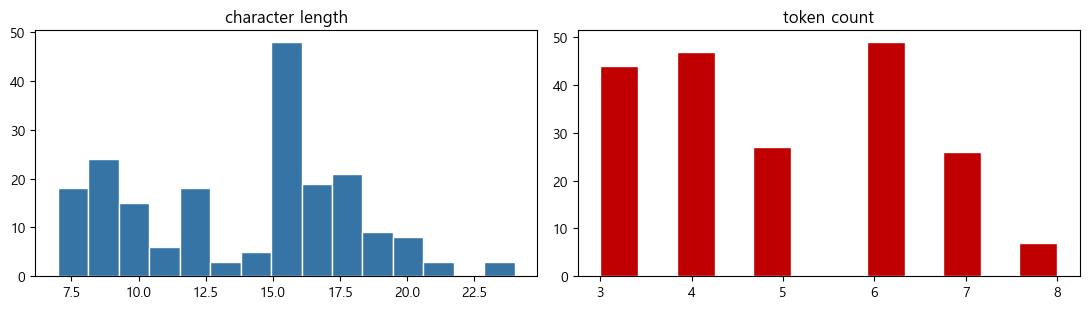

In [127]:
# ===== EDA ③ (선택) 길이 분포 시각화 =====
if HAS_PLT:
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
    ax[0].hist(df['n_chars'], bins=15, color='#3774A6', edgecolor='white')
    ax[0].set_title('character length')
    ax[1].hist(df['n_tokens'], bins=12, color='#C00000', edgecolor='white')
    ax[1].set_title('token count')
    plt.tight_layout(); plt.show()
else:
    print('matplotlib 이 없어 시각화는 건너뜁니다.')
    print('문자 길이 분포 :')
    print(df['n_chars'].value_counts(bins=6).sort_index().to_string())

## 2-2. 학습 / 검증 데이터 분리

> ⚠️ **가장 중요한 원칙** : 벡터화기(어휘 사전)는 **반드시 학습 데이터로만** 만들어야 합니다.
> 전체 데이터로 어휘 사전을 만들면 검증 데이터의 정보가 새어 나가는
> **데이터 누수(Data Leakage)** 가 발생해 성능이 과대평가됩니다.

In [128]:
# ===== 2-2. 층화 분할 (라벨 비율 유지) =====
def stratified_split(df, test_size=0.25, seed=42):
    rng = np.random.RandomState(seed)
    tr_idx, te_idx = [], []
    for lab in sorted(df['label'].unique()):
        idx = df.index[df['label'] == lab].to_numpy()
        rng.shuffle(idx)
        cut = int(len(idx) * test_size)
        te_idx.extend(idx[:cut]); tr_idx.extend(idx[cut:])
    rng.shuffle(tr_idx); rng.shuffle(te_idx)
    return df.loc[tr_idx].reset_index(drop=True), df.loc[te_idx].reset_index(drop=True)

train_df, test_df = stratified_split(df)
print(f'학습 {len(train_df)}건 (긍정 {int(train_df.label.sum())} / 부정 {int((1-train_df.label).sum())})')
print(f'검증 {len(test_df)}건 (긍정 {int(test_df.label.sum())} / 부정 {int((1-test_df.label).sum())})')

학습 150건 (긍정 75 / 부정 75)
검증 50건 (긍정 25 / 부정 25)


In [129]:
# ===== 2-3. TF-IDF 벡터화 (학습 데이터 기준) =====

# ① 어휘 사전은 학습 데이터로만 구축
#    (코퍼스가 작으므로 min_count=1, 대규모 데이터에서는 2~5 를 사용)
vocab_tr = build_vocab(train_df['tokens'], min_count=1)
V_tr = len(vocab_tr)
print('학습 데이터 어휘 사전 크기 :', V_tr)

# ② DTM
DTM_tr = build_dtm(train_df['tokens'], vocab_tr)
DTM_te = build_dtm(test_df['tokens'], vocab_tr)     # 같은 사전으로 변환

# ③ IDF 도 학습 데이터에서만 계산해 검증 데이터에 그대로 적용
idf_tr = compute_idf(DTM_tr)
X_tr = l2_normalize(DTM_tr * idf_tr)
X_te = l2_normalize(DTM_te * idf_tr)
y_tr = train_df['label'].to_numpy()
y_te = test_df['label'].to_numpy()

print('X_tr :', X_tr.shape, ' X_te :', X_te.shape)

# 검증 데이터에서 어휘 사전에 없는 단어(OOV) 비율
oov = np.mean([sum(t not in vocab_tr for t in toks) / max(len(toks), 1)
               for toks in test_df['tokens']])
print(f'검증 데이터의 OOV(사전에 없는 단어) 비율 : {oov:.1%}')

학습 데이터 어휘 사전 크기 : 272
X_tr : (150, 272)  X_te : (50, 272)
검증 데이터의 OOV(사전에 없는 단어) 비율 : 19.4%


## 2-4. 모델 ① 나이브 베이즈 (Multinomial Naive Bayes)

$$\hat{c} = \arg\max_c\ \Big[\ \log P(c) + \sum_{t \in d} \text{count}(t,d)\cdot \log P(t \mid c)\ \Big]$$

$$P(t \mid c) = \frac{\text{count}(t, c) + \alpha}{\sum_{t'} \text{count}(t', c) + \alpha V}\quad (\text{라플라스 스무딩})$$

확률을 그대로 곱하면 값이 0에 수렴해 버리므로 **로그를 취해 덧셈으로 계산**합니다.

In [130]:
# ===== 2-4. 나이브 베이즈 직접 구현 =====
# 클래스 이름을 MyMultinomialNB 로 둔다.
# sklearn.naive_bayes.MultinomialNB 와 이름이 겹치면, 뒤에서 sklearn 을 import 했을 때
# 어느 쪽이 쓰이는지 알 수 없게 되기 때문이다. (이름 가림 / shadowing)
class MyMultinomialNB:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_features = X.shape[1]
        self.log_prior_ = np.zeros(len(self.classes_))
        self.log_lik_ = np.zeros((len(self.classes_), n_features))
        for i, c in enumerate(self.classes_):
            Xc = X[y == c]
            self.log_prior_[i] = np.log(len(Xc) / len(X))
            counts = Xc.sum(axis=0) + self.alpha           # 라플라스 스무딩
            self.log_lik_[i] = np.log(counts / counts.sum())
        return self

    def decision(self, X):
        return X @ self.log_lik_.T + self.log_prior_

    def predict(self, X):
        return self.classes_[np.argmax(self.decision(X), axis=1)]

nb = MyMultinomialNB(alpha=1.0).fit(X_tr, y_tr)
pred_nb = nb.predict(X_te)
print('나이브 베이즈 검증 정확도 : {:.3f}'.format((pred_nb == y_te).mean()))


나이브 베이즈 검증 정확도 : 0.800


## 2-5. 모델 ② 로지스틱 회귀 (Logistic Regression)

$$\hat{y} = \sigma(\mathbf{w}^\top \mathbf{x} + b), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

손실 함수는 **이진 교차 엔트로피**이고, 경사하강법으로 가중치를 갱신합니다.

$$\mathcal{L} = -\frac{1}{n}\sum_i \big[\, y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i) \,\big] + \lambda \lVert \mathbf{w} \rVert^2$$

In [131]:
# ===== 2-5. 로지스틱 회귀 직접 구현 (경사하강법 + L2 규제) =====
class LogisticRegressionGD:
    def __init__(self, lr=1.0, n_iter=800, l2=1e-4):
        self.lr, self.n_iter, self.l2 = lr, n_iter, l2

    @staticmethod #self를 쓰지 않는 함수라는 표시
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

    def fit(self, X, y, verbose=False):
        n, m = X.shape
        self.w = np.zeros(m); self.b = 0.0
        self.history_ = []
        for it in range(self.n_iter):
            p = self._sigmoid(X @ self.w + self.b)
            err = p - y
            #예측(순전파)
            #문서마다 <TF-IDF값 X 그 단어 가중치>를 모두 더한 점수가 나오고
            #여기에 편향 b까지 더한 다음 시그모이드를 씌우면 각 문서가 긍정적일 확률p
            
            self.w -= self.lr * (X.T @ err / n + 2 * self.l2 * self.w)
            self.b -= self.lr * err.mean()
            #단어별 기울기(X.T @ err / n)를 구하는데,TF-IDF 값 × 오차를 모든 문서에 대해 평균낸 값
            #L2 규제항 λ‖w‖²를 미분한 값을 곱해줌
            
            loss = -np.mean(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12))
            self.history_.append(loss)
            #이진 교차 엔트로피
            #정답이 1이면 −log p, 0이면 −log(1−p)만 남아서
            #정답에 낮은 확률을 줄수록 손실이 커짐
            
            if verbose and it % 200 == 0:
                print(f'  iter {it:4d}  loss {loss:.4f}')
        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w + self.b) 
    #긍정일 확률 출력        

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print('[로지스틱 회귀 학습]')
lr_model = LogisticRegressionGD(lr=2.0, n_iter=1200).fit(X_tr, y_tr, verbose=True)
pred_lr = lr_model.predict(X_te)
print('로지스틱 회귀 검증 정확도 : {:.3f}'.format((pred_lr == y_te).mean()))

[로지스틱 회귀 학습]
  iter    0  loss 0.6931
  iter  200  loss 0.2421
  iter  400  loss 0.1513
  iter  600  loss 0.1144
  iter  800  loss 0.0953
  iter 1000  loss 0.0840
로지스틱 회귀 검증 정확도 : 0.860


* 첫 손실 0.6931 = log 2: 가중치가 전부 0이라 모든 문서를 확률 0.5로 예측한 상태.
* 반복할수록 손실이 0.084까지 꾸준히 줄어들어 학습이 잘 된 것.
* 검증 정확도 0.86은 나이브 베이즈(0.80)보다 높음.
* iter 1000에서 검증 정확도는 86%. 학습 데이터는 거의 외웠지만, 처음 보는 데이터에서는 50건 중 7건을 틀린다는 뜻

In [132]:
# ===== 로지스틱 회귀의 해석력 : 어떤 단어가 긍정/부정에 기여했는가 =====
inv_tr = {i: w for w, i in vocab_tr.items()}
order = np.argsort(lr_model.w)
print('[부정(0)에 기여한 단어 10개]')
print([(inv_tr[i], round(lr_model.w[i], 3)) for i in order[:10]])
print('\n[긍정(1)에 기여한 단어 10개]')
print([(inv_tr[i], round(lr_model.w[i], 3)) for i in order[-10:]])

[부정(0)에 기여한 단어 10개]
[('실망', np.float64(-5.598)), ('지루', np.float64(-4.509)), ('형편없', np.float64(-4.343)), ('산만', np.float64(-4.169)), ('촌', np.float64(-4.093)), ('아쉽', np.float64(-3.787)), ('어색', np.float64(-3.693)), ('뻔', np.float64(-3.416)), ('최악', np.float64(-3.321)), ('전혀', np.float64(-2.674))]

[긍정(1)에 기여한 단어 10개]
[('잘', np.float64(2.549)), ('자연', np.float64(2.574)), ('아주', np.float64(2.865)), ('신선', np.float64(2.941)), ('매력적', np.float64(3.254)), ('만족', np.float64(3.727)), ('뛰어나', np.float64(3.808)), ('인상적', np.float64(4.524)), ('좋다', np.float64(5.121)), ('훌륭', np.float64(5.356))]


## 2-6. 성능 평가 : 혼동 행렬과 지표

|            | 예측 : 긍정 | 예측 : 부정 |
|---|---|---|
| **실제 : 긍정** | TP | FN |
| **실제 : 부정** | FP | TN |

$$\text{Accuracy}=\frac{TP+TN}{\text{전체}},\quad
\text{Precision}=\frac{TP}{TP+FP},\quad
\text{Recall}=\frac{TP}{TP+FN},\quad
F_1=\frac{2PR}{P+R}$$

In [133]:
# ===== 2-6. 평가 지표 직접 구현 =====
def confusion_matrix(y_true, y_pred):
    TP = int(((y_true == 1) & (y_pred == 1)).sum())
    FN = int(((y_true == 1) & (y_pred == 0)).sum())
    FP = int(((y_true == 0) & (y_pred == 1)).sum())
    TN = int(((y_true == 0) & (y_pred == 0)).sum())
    return TP, FN, FP, TN

def classification_scores(y_true, y_pred):
    TP, FN, FP, TN = confusion_matrix(y_true, y_pred)
    acc = (TP + TN) / max(TP + FN + FP + TN, 1)
    prec = TP / max(TP + FP, 1)
    rec = TP / max(TP + FN, 1)
    f1 = 2 * prec * rec / max(prec + rec, 1e-12)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

TP, FN, FP, TN = confusion_matrix(y_te, pred_lr)
display(pd.DataFrame([[TP, FN], [FP, TN]],
                     index=['실제 : 긍정', '실제 : 부정'],
                     columns=['예측 : 긍정', '예측 : 부정']))
print(classification_scores(y_te, pred_lr))

,예측 : 긍정,예측 : 부정
실제 : 긍정,22,3
실제 : 부정,4,21


{'accuracy': 0.86, 'precision': 0.8461538461538461, 'recall': 0.88, 'f1': 0.8627450980392156}


In [134]:
# ===== 세 모델 비교 =====
results = {
    '나이브 베이즈': classification_scores(y_te, pred_nb),
    '로지스틱 회귀': classification_scores(y_te, pred_lr),
}

# (선택) 랜덤 포레스트는 scikit-learn 이 있을 때만
if HAS_SKLEARN:
    from sklearn.ensemble import RandomForestClassifier
    rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_tr, y_tr)
    pred_rf = rf.predict(X_te)
    results['랜덤 포레스트'] = classification_scores(y_te, pred_rf)
else:
    print('scikit-learn 이 없어 랜덤 포레스트는 건너뜁니다.')

display(pd.DataFrame(results).T.round(3))

,accuracy,precision,recall,f1
나이브 베이즈,0.80,0.778,0.84,0.808
로지스틱 회귀,0.86,0.846,0.88,0.863
랜덤 포레스트,0.82,0.864,0.76,0.809


In [135]:
# ===== 새로운 문장으로 예측해 보기 =====
def predict_sentence(text, model=lr_model):
    toks = tokenize(text)
    d = build_dtm([toks], vocab_tr)
    x = l2_normalize(d * idf_tr)
    p = float(model.predict_proba(x)[0])
    return p, ('긍정' if p >= 0.5 else '부정')

for s in ["연출이 훌륭하고 배우 연기가 정말 좋았다",
          "지루하고 시간이 아까운 영화였다",
          "음악은 좋았지만 스토리가 너무 뻔하다"]:
    p, lab = predict_sentence(s)
    print(f'{lab}  (긍정 확률 {p:.3f})  ← {s}')

긍정  (긍정 확률 0.963)  ← 연출이 훌륭하고 배우 연기가 정말 좋았다
부정  (긍정 확률 0.049)  ← 지루하고 시간이 아까운 영화였다
부정  (긍정 확률 0.029)  ← 음악은 좋았지만 스토리가 너무 뻔하다


### ✅ Part 2 검증

In [136]:
# ===== Part 2 자가 검증 =====
checks = []
checks.append(('학습/검증 분리 완료', len(train_df) + len(test_df) == len(df)))
checks.append(('층화 분할 (라벨 비율 유지)',
               abs(train_df.label.mean() - test_df.label.mean()) < 0.15))
checks.append(('검증 데이터도 같은 차원', X_te.shape[1] == X_tr.shape[1]))
checks.append(('나이브 베이즈 정확도 >= 0.7', (pred_nb == y_te).mean() >= 0.7))
checks.append(('로지스틱 회귀 정확도 >= 0.7', (pred_lr == y_te).mean() >= 0.7))
checks.append(('손실이 감소했는가', lr_model.history_[-1] < lr_model.history_[0]))
_s = classification_scores(np.array([1, 1, 0, 0]), np.array([1, 0, 0, 0]))
checks.append(('평가 지표 계산 정확', abs(_s['precision'] - 1.0) < 1e-9
               and abs(_s['recall'] - 0.5) < 1e-9))

for name, ok in checks:
    print(('  통과   ' if ok else '  실패 ! ') + name)
print('\n결과 : {}/{} 통과'.format(sum(o for _, o in checks), len(checks)))

  통과   학습/검증 분리 완료
  통과   층화 분할 (라벨 비율 유지)
  통과   검증 데이터도 같은 차원
  통과   나이브 베이즈 정확도 >= 0.7
  통과   로지스틱 회귀 정확도 >= 0.7
  통과   손실이 감소했는가
  통과   평가 지표 계산 정확

결과 : 7/7 통과


---
---
# Part 3. 텍스트 유사도 (Text Similarity)

> **핵심 질문** : 두 문서가 얼마나 비슷한지를 어떻게 하나의 숫자로 나타낼 것인가?

이번 파트에서는 네 가지 유사도를 직접 구현하고, 마지막에 **미니 검색기**를 만들어 봅니다.

| 유사도 | 수식 | 벡터화 필요 |
|---|---|---|
| 자카드 | \| A ∩ B \| / \| A ∪ B \| | 불필요 |
| 코사인 | (A·B) / (‖A‖‖B‖) | 필요 |
| 유클리디언 | √Σ(aᵢ−bᵢ)² | 필요 |
| 맨해튼 | Σ\|aᵢ−bᵢ\| | 필요 |

In [137]:
# ===== 3-0. 비교에 사용할 두 문장 =====
sent_a = "휴일인 오늘도 서쪽을 중심으로 폭염이 이어졌는데요 내일은 반가운 비 소식이 있습니다"
sent_b = "폭염을 피해서 휴일에 놀러왔다가 갑작스런 비로 인해 망연자실하고 있습니다"

tok_a, tok_b = tokenize(sent_a), tokenize(sent_b)
print('A :', tok_a)
print('B :', tok_b)

# 두 문장만으로 별도의 TF-IDF 벡터 생성
pair_tokens = [tok_a, tok_b]
pair_vocab = build_vocab(pair_tokens)
pair_dtm = build_dtm(pair_tokens, pair_vocab)
pair_tfidf = compute_tfidf(pair_dtm)      # L2 정규화까지 포함
print('\n어휘 사전 크기 :', len(pair_vocab))
print('TF-IDF 행렬 :', pair_tfidf.shape)

A : ['휴일', '오늘', '도', '서쪽', '을', '중심', '으로', '폭염', '이', '이어졌는데요', '내일', '은', '반가운', '비', '소식', '이', '있']
B : ['폭염', '을', '피', '휴일', '에', '놀러왔', '가', '갑작', '비로', '인해', '망연자실', '있']

어휘 사전 크기 : 24
TF-IDF 행렬 : (2, 24)


## 3-1. 자카드 유사도 (Jaccard Similarity)

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

집합만 사용하므로 **벡터화가 필요 없고**, 값은 항상 `0 ~ 1` 입니다.
단, **단어의 등장 횟수는 전혀 반영하지 못합니다.**

In [138]:
# ===== 3-1. 자카드 유사도 =====
def jaccard_similarity(tokens1, tokens2):
    A, B = set(tokens1), set(tokens2)
    if not A and not B:
        return 1.0
    return len(A & B) / len(A | B)

A, B = set(tok_a), set(tok_b)
print('교집합 ({}개) : {}'.format(len(A & B), sorted(A & B)))
print('합집합 ({}개)'.format(len(A | B)))
jac = jaccard_similarity(tok_a, tok_b)
print('\n자카드 유사도 = {}/{} = {:.3f}'.format(len(A & B), len(A | B), jac))

# 빈도를 무시한다는 한계 확인
print('\n["영화 재미" vs "영화 영화 영화 재미"] 자카드 =',
      jaccard_similarity('영화 재미'.split(), '영화 영화 영화 재미'.split()), ' ← 빈도 차이를 못 봄')

교집합 (4개) : ['을', '있', '폭염', '휴일']
합집합 (24개)

자카드 유사도 = 4/24 = 0.167

["영화 재미" vs "영화 영화 영화 재미"] 자카드 = 1.0  ← 빈도 차이를 못 봄


## 3-2. 코사인 유사도 (Cosine Similarity)

$$\cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\lVert \mathbf{A}\rVert \, \lVert \mathbf{B}\rVert}$$

**두 벡터가 이루는 각도**만 보기 때문에 **문서 길이의 영향을 받지 않습니다.**
텍스트 유사도의 사실상 표준 척도입니다.

In [139]:
# ===== 3-2. 코사인 유사도 =====
def cosine_similarity(v1, v2):
    n1, n2 = np.linalg.norm(v1), np.linalg.norm(v2)
    if n1 == 0 or n2 == 0:
        return 0.0
    return float(np.dot(v1, v2) / (n1 * n2))

cos = cosine_similarity(pair_tfidf[0], pair_tfidf[1])
print('코사인 유사도 = {:.3f}'.format(cos))

# 문서 길이에 영향받지 않음을 확인
v_short = np.array([1.0, 1.0])          # "영화 재미"
v_long  = np.array([2.0, 2.0])          # "영화 영화 재미 재미"
print('\n[1,1] vs [2,2]')
print('  코사인      = {:.3f}   ← 방향이 같으므로 1.0'.format(cosine_similarity(v_short, v_long)))
print('  유클리디언 거리 = {:.3f}   ← 길이가 다르면 멀다고 판정'.format(np.linalg.norm(v_short - v_long)))

코사인 유사도 = 0.155

[1,1] vs [2,2]
  코사인      = 1.000   ← 방향이 같으므로 1.0
  유클리디언 거리 = 1.414   ← 길이가 다르면 멀다고 판정


## 3-3. 유클리디언 · 맨해튼 유사도

$$d_{L2}(A,B)=\sqrt{\sum_i (a_i-b_i)^2}, \qquad d_{L1}(A,B)=\sum_i |a_i-b_i|$$

둘 다 **거리**이므로 **값이 작을수록 유사**하고, 값의 범위에 제한이 없습니다.
따라서 비교 가능하게 만들려면 **L1 정규화**(성분의 합을 1로) 후 계산합니다.

In [140]:
# ===== 3-3. 거리 기반 유사도 =====
def l1_normalize(v):
    s = np.sum(np.abs(v))
    return v / s if s != 0 else v

def euclidean_distance(v1, v2):
    return float(np.sqrt(np.sum((v1 - v2) ** 2)))

def manhattan_distance(v1, v2):
    return float(np.sum(np.abs(v1 - v2)))

raw_eu = euclidean_distance(pair_tfidf[0], pair_tfidf[1])
raw_mh = manhattan_distance(pair_tfidf[0], pair_tfidf[1])

n0, n1 = l1_normalize(pair_tfidf[0]), l1_normalize(pair_tfidf[1])
nrm_eu = euclidean_distance(n0, n1)
nrm_mh = manhattan_distance(n0, n1)

print('정규화 전  유클리디언 = {:.3f} / 맨해튼 = {:.3f}'.format(raw_eu, raw_mh))
print('L1 정규화 후 유클리디언 = {:.3f} / 맨해튼 = {:.3f}'.format(nrm_eu, nrm_mh))
print('\n※ 거리이므로 값이 작을수록 유사합니다. (유사도와 방향이 반대)')

정규화 전  유클리디언 = 1.300 / 맨해튼 = 5.886
L1 정규화 후 유클리디언 = 0.360 / 맨해튼 = 1.641

※ 거리이므로 값이 작을수록 유사합니다. (유사도와 방향이 반대)


In [141]:
# ===== 네 가지 유사도 한눈에 비교 =====
summary = pd.DataFrame([
    ['자카드',                 round(jac, 3),    '클수록 유사 (0~1)'],
    ['코사인',                 round(cos, 3),    '클수록 유사 (0~1)'],
    ['유클리디언 (L1 정규화)', round(nrm_eu, 3), '작을수록 유사 (거리)'],
    ['맨해튼 (L1 정규화)',     round(nrm_mh, 3), '작을수록 유사 (거리)'],
], columns=['유사도', '계산 값', '해석'])
display(summary)
print('※ 척도마다 스케일이 다르므로 절대값 비교는 의미가 없고,')
print('  동일한 척도 안에서의 순위 비교가 중요합니다.')
print('  자카드는 겹치는 단어 종류의 비율을 (클수록 유사)')
print('  코사인은 두 벡터의 방향(각도)을 (클수록 유사)')
print('  유클리디언은 두 점 사이의 직선 거리를 (작을수록 유사)')
print('  맨해튼은 성분 차이의 절댓값의 합을 구합니다. (작을수록 유사)')


,유사도,계산 값,해석
0,자카드,0.167,클수록 유사 (0~1)
1,코사인,0.155,클수록 유사 (0~1)
2,유클리디언 (L1 정규화),0.360,작을수록 유사 (거리)
3,맨해튼 (L1 정규화),1.641,작을수록 유사 (거리)


※ 척도마다 스케일이 다르므로 절대값 비교는 의미가 없고,
  동일한 척도 안에서의 순위 비교가 중요합니다.
  자카드는 겹치는 단어 종류의 비율을 (클수록 유사)
  코사인은 두 벡터의 방향(각도)을 (클수록 유사)
  유클리디언은 두 점 사이의 직선 거리를 (작을수록 유사)
  맨해튼은 성분 차이의 절댓값의 합을 구합니다. (작을수록 유사)


In [142]:
# ===== (선택) scikit-learn 결과와 비교 =====
if HAS_SKLEARN:
    from sklearn.metrics.pairwise import (cosine_similarity as sk_cos,
                                          euclidean_distances as sk_eu,
                                          manhattan_distances as sk_mh)
    print('코사인      : 우리 {:.6f} / sklearn {:.6f}'.format(
        cos, float(sk_cos(pair_tfidf[0:1], pair_tfidf[1:2])[0][0])))
    print('유클리디언  : 우리 {:.6f} / sklearn {:.6f}'.format(
        nrm_eu, float(sk_eu(n0.reshape(1, -1), n1.reshape(1, -1))[0][0])))
    print('맨해튼      : 우리 {:.6f} / sklearn {:.6f}'.format(
        nrm_mh, float(sk_mh(n0.reshape(1, -1), n1.reshape(1, -1))[0][0])))
else:
    print('scikit-learn 이 없어 이 셀은 건너뜁니다.')

코사인      : 우리 0.155001 / sklearn 0.155001
유클리디언  : 우리 0.359803 / sklearn 0.359803
맨해튼      : 우리 1.640789 / sklearn 1.640789


## 3-4. 응용 : TF-IDF + 코사인 유사도 기반 미니 검색기

검색 엔진의 가장 기본적인 원리입니다.

1. 모든 문서를 TF-IDF 벡터로 만들어 둔다
2. 질의(query)도 **같은 어휘 사전과 같은 IDF** 로 벡터화한다
3. 질의 벡터와 모든 문서 벡터의 **코사인 유사도**를 계산한다
4. 유사도가 높은 순으로 정렬해 상위 k개를 반환한다

In [143]:
# ===== 3-4. 미니 검색기 =====
class MiniSearchEngine:
    def __init__(self, documents):
        self.documents = documents
        self.token_lists = [tokenize(d) for d in documents]
        self.vocab = build_vocab(self.token_lists)
        dtm = build_dtm(self.token_lists, self.vocab)
        self.idf = compute_idf(dtm)
        self.matrix = l2_normalize(dtm * self.idf)     # 문서 벡터 (미리 계산)

    def _vectorize(self, text):
        d = build_dtm([tokenize(text)], self.vocab)
        return l2_normalize(d * self.idf)[0]

    def search(self, query, top_k=5):
        q = self._vectorize(query)
        scores = self.matrix @ q                       # 이미 L2 정규화 → 내적 = 코사인
        order = np.argsort(-scores)[:top_k]
        return [(int(i), float(scores[i]), self.documents[i]) for i in order]

engine = MiniSearchEngine(df['text'].tolist())
print('색인된 문서 수 :', len(engine.documents), ' / 어휘 사전 :', len(engine.vocab), '\n')

for query in ["배우 연기가 훌륭한 영화", "지루하고 시간이 아까운"]:
    print(f'[질의] {query}')
    for rank, (i, score, doc) in enumerate(engine.search(query, top_k=3), 1):
        print(f'  {rank}위 (유사도 {score:.3f}) {doc}')
    print()

색인된 문서 수 : 200  / 어휘 사전 : 322 

[질의] 배우 연기가 훌륭한 영화
  1위 (유사도 0.877) 배우 연기가 훌륭하다
  2위 (유사도 0.804) 이 영화 정말 재미있고 배우 연기가 훌륭하다
  3위 (유사도 0.601) 배우 연기가 자연스럽다

[질의] 지루하고 시간이 아까운
  1위 (유사도 0.649) 시간이 아까운 최악의 영화였다
  2위 (유사도 0.356) 구성이 지루하다
  3위 (유사도 0.337) 연기력이 지루하다



In [144]:
# ===== 응용 : 중복(유사) 문서 쌍 탐지 =====
S = engine.matrix @ engine.matrix.T          # 전체 문서 쌍 코사인 유사도 행렬
np.fill_diagonal(S, 0)                       # 자기 자신 제외

pairs = []
for i in range(len(S)):
    for j in range(i + 1, len(S)):
        pairs.append((S[i, j], i, j))
pairs.sort(reverse=True)

print('가장 유사한 문서 쌍 5개')
for score, i, j in pairs[:5]:
    print(f'  유사도 {score:.3f}')
    print(f'    [{i}] {engine.documents[i]}')
    print(f'    [{j}] {engine.documents[j]}')

가장 유사한 문서 쌍 5개
  유사도 0.720
    [118] 캐릭터가 지루하다
    [178] 캐릭터가 전형적이고 지루하다
  유사도 0.706
    [107] 배우 연기가 훌륭하다
    [111] 이 영화 정말 재미있고 배우 연기가 훌륭하다
  유사도 0.697
    [11] 각본이 매우 아쉽다
    [12] 연출이 매우 아쉽다
  유사도 0.697
    [8] 음악이 매우 아쉽다
    [11] 각본이 매우 아쉽다
  유사도 0.687
    [60] 캐릭터가 아주 어색하다
    [162] 스토리가 아주 어색하다


### 한계 확인 : 단어가 겹치지 않으면 유사도는 0

의미가 아무리 비슷해도 **표면적인 단어가 겹치지 않으면** 횟수 기반 유사도는 `0` 입니다.
이 한계는 `Word2Vec`, `Sentence-BERT` 같은 **임베딩 기반 유사도**로 보완합니다.

In [145]:
# ===== 횟수 기반 유사도의 한계 =====
pairs_demo = [
    ("자동차 가격이 궁금하다", "차량 시세가 알고 싶다"),      # 의미는 같지만 단어가 다름
    ("이 영화는 재미있다",     "이 영화는 재미없다"),          # 단어는 거의 같지만 의미가 반대
]
for s1, s2 in pairs_demo:
    tks = [tokenize(s1), tokenize(s2)]
    vb = build_vocab(tks)
    mt = compute_tfidf(build_dtm(tks, vb))
    print(f'"{s1}"  vs  "{s2}"')
    print('   자카드 = {:.3f} / 코사인 = {:.3f}\n'.format(
        jaccard_similarity(*tks), cosine_similarity(mt[0], mt[1])))

"자동차 가격이 궁금하다"  vs  "차량 시세가 알고 싶다"
   자카드 = 0.000 / 코사인 = 0.000

"이 영화는 재미있다"  vs  "이 영화는 재미없다"
   자카드 = 0.600 / 코사인 = 0.603



### ✅ Part 3 검증

In [146]:
# ===== Part 3 자가 검증 =====
checks = []
checks.append(('자카드 : 같은 집합이면 1',
               abs(jaccard_similarity(['a', 'b'], ['b', 'a']) - 1.0) < 1e-9))
checks.append(('자카드 : 겹치지 않으면 0',
               abs(jaccard_similarity(['a'], ['b']) - 0.0) < 1e-9))
checks.append(('코사인 : 자기 자신과는 1',
               abs(cosine_similarity(pair_tfidf[0], pair_tfidf[0]) - 1.0) < 1e-9))
checks.append(('코사인 : 길이에 무관',
               abs(cosine_similarity(np.array([1., 1.]), np.array([5., 5.])) - 1.0) < 1e-9))
checks.append(('유클리디언 : 자기 자신과는 0',
               abs(euclidean_distance(pair_tfidf[0], pair_tfidf[0])) < 1e-12))
checks.append(('맨해튼 >= 유클리디언 (항상 성립)', nrm_mh >= nrm_eu - 1e-12))
checks.append(('L1 정규화 후 합 = 1', abs(np.sum(np.abs(n0)) - 1.0) < 1e-9))
checks.append(('검색 결과 개수', len(engine.search('영화', top_k=3)) == 3))

for name, ok in checks:
    print(('  통과   ' if ok else '  실패 ! ') + name)
print('\n결과 : {}/{} 통과'.format(sum(o for _, o in checks), len(checks)))

  통과   자카드 : 같은 집합이면 1
  통과   자카드 : 겹치지 않으면 0
  통과   코사인 : 자기 자신과는 1
  통과   코사인 : 길이에 무관
  통과   유클리디언 : 자기 자신과는 0
  통과   맨해튼 >= 유클리디언 (항상 성립)
  통과   L1 정규화 후 합 = 1
  통과   검색 결과 개수

결과 : 8/8 통과


---
---
# 📌 과제 (총 100점)

아래 5문항의 `raise NotImplementedError(...)` 부분을 직접 채운 뒤, **각 문항 아래의 채점 셀** 을 실행한다.
채점 셀은 통과 여부만 알려 주며, **모범 답안은 출력하지 않는다.**

| 번호 | 과제 | 배점 |
|:---:|---|:---:|
| 과제 1 | 서브리니어 TF · BM25 계열 IDF 구현 | 20 |
| 과제 2 | 변형 TF-IDF 행렬 구현 및 Part 1 과의 비교 | 20 |
| 과제 3 | 불용어 제거의 효과 관찰 | 20 |
| 과제 4 | 하이브리드 유사도(자카드 + 코사인) 구현 | 20 |
| 과제 5 | 스무딩 계수 탐색과 모델 비교 해석 | 20 |

- 제출 파일명 : `5주차_실습_학번_이름.ipynb`
- **모든 셀을 위에서부터 실행하여 출력이 보이는 상태로** 저장해 제출한다.
- 과제 1 · 2 · 4 는 Part 1 ~ 3 의 함수를 **그대로 다시 쓰는 문제가 아니다.**
  Part 1 ~ 3 의 코드는 참고만 하고, 각 문항이 요구하는 **변형된 식** 을 직접 구현해야 한다.


In [147]:
# ===== 채점 도구 (수정하지 마세요) =====
# 이 도구는 통과 여부와 '통과하지 못한 조건' 만 알려 준다.
# 모범 답안(정답 코드)은 어떤 경우에도 출력하지 않는다.
SCORE = {}


def grade(no, name, ok, points, reason=''):
    """채점 결과를 SCORE 에 기록하고 한 줄로 출력한다."""
    SCORE[no] = points if ok else 0
    if ok:
        print(f'통과!  과제 {no}. {name}  ({points}/{points}점)')
    else:
        print(f'✗ 실패  과제 {no}. {name}  (0/{points}점)')
        if reason:
            print('   통과하지 못한 조건 :', reason)
    return bool(ok)


## 과제 1. 서브리니어 TF 와 BM25 계열 IDF 구현 (20점)

Part 1 에서는 TF 를 **등장 횟수 그대로** 썼고, IDF 는 $\log\frac{1+N}{1+\text{DF}(t)} + 1$ (smooth IDF)를 썼다.
여기서는 실제 검색 엔진에서 널리 쓰이는 **두 가지 변형** 을 직접 구현한다. **Part 1 의 함수를 그대로 쓰면 통과하지 못한다.**

**(1) 서브리니어 TF (sublinear TF scaling)**

$$\text{tf}_{sub}(t,d) = 1 + \log \text{tf}(t,d) \;\; (\text{tf} > 0), \qquad \text{tf}_{sub}(t,d) = 0 \;\; (\text{tf} = 0)$$

같은 단어가 10번 나왔다고 해서 1번 나온 문서보다 10배 중요한 것은 아니다.
로그를 씌워 **횟수가 늘어날 때의 증가 폭을 완만하게** 만든다.

**개념: 횟수가 늘어날수록 추가로 주는 정보가 줄어드니 로그를 씌워 증가폭을 완만하게 만듦**

**(2) BM25 계열 IDF**

$$\text{idf}_{bm25}(t) = \log\left(1 + \frac{N - \text{DF}(t) + 0.5}{\text{DF}(t) + 0.5}\right)$$

smooth IDF 와 달리 **흔한 단어의 가중치를 훨씬 더 강하게 깎는다.** 값은 항상 0보다 크다.

**요구 사항**

1. `sublinear_tf(dtm)` — `dtm` 과 **같은 shape** 의 배열을 반환한다. 0 인 자리는 0 그대로 둔다.
2. `bm25_idf(dtm)` — 길이 `V` 의 1차원 IDF 벡터를 반환한다. 로그는 `np.log`(자연로그)를 쓴다.
3. `DF(t)` 는 단어 `t` 의 **등장 횟수가 아니라 등장한 문서의 수** 다.
4. 두 함수 모두 `for` 문 없이 numpy 연산만으로 작성할 수 있다. (`for` 문을 써도 정답으로 인정)


In [148]:
# ── 과제 1 ────────────────────────────────────────────────────────
def sublinear_tf(dtm):
    """
    dtm : (문서 수 N, 어휘 수 V) 형태의 numpy 배열 (등장 횟수)
    반환 : 같은 shape 의 서브리니어 TF 행렬 (tf > 0 이면 1 + log(tf), tf == 0 이면 0)
    """
    # TODO 1 : dtm 과 같은 shape 의 0 행렬을 만든다 (np.zeros_like(dtm, dtype=float))
    # TODO 2 : dtm > 0 인 위치에만 1 + np.log(...) 값을 채워 넣는다
    #          (0 에 로그를 씌우면 -inf 가 되므로 반드시 마스크로 걸러야 한다)
    # TODO 3 : 완성된 행렬을 반환한다
    out = np.zeros_like(dtm, dtype=float) #로그결과(소수)를 붙이려고 float처리
    mask = dtm > 0 #mask는 dtm과 같은 모양의 True/False 행렬이다
    out[mask] = 1 + np.log(dtm[mask]) 
    return out


def bm25_idf(dtm):
    """
    dtm : (N, V) 문서 단어 행렬
    반환 : 길이 V 의 IDF 벡터
    """
    # TODO 4 : 전체 문서 수 N 과 각 단어의 DF 를 구한다 (DF 는 '등장한 문서 수')
    # TODO 5 : log(1 + (N - DF + 0.5) / (DF + 0.5)) 를 그대로 적용해 반환한다
    N = dtm.shape[0]
    df_ = (dtm > 0).sum(axis=0)
    return np.log(1 + (N - df_ + 0.5) / (df_ + 0.5))


# 확인 : 내가 만든 함수의 출력만 살펴본다
try:
    _demo = np.array([[0., 1., 2., 4., 8.]])
    print('서브리니어 TF  입력 :', _demo[0])
    print('서브리니어 TF  출력 :', np.round(sublinear_tf(_demo)[0], 4))
    print('  ↑ 횟수가 2배가 되어도 값은 2배가 되지 않는다(로그 압축).')
    print()
    print('BM25 IDF (mini 코퍼스) :', np.round(bm25_idf(mini_dtm), 4))
    print('어휘 :', list(mini_vocab.keys()))
    print('DF   :', compute_df(mini_dtm))
    print('  ↑ DF 가 큰 단어일수록 IDF 가 작아야 한다.')
except NotImplementedError as e:
    print('▶ 미구현 :', e)


서브리니어 TF  입력 : [0. 1. 2. 4. 8.]
서브리니어 TF  출력 : [0.    1.    1.693 2.386 3.079]
  ↑ 횟수가 2배가 되어도 값은 2배가 되지 않는다(로그 압축).

BM25 IDF (mini 코퍼스) : [0.47  0.47  0.981 0.981]
어휘 : ['영화', '재미', '지루', '추천']
DF   : [2 2 1 1]
  ↑ DF 가 큰 단어일수록 IDF 가 작아야 한다.


In [149]:
# [과제 1] 채점 — 기대 조건이 하드코딩되어 있다.
_name1 = '서브리니어 TF · BM25 IDF 구현'
try:
    # (1) 서브리니어 TF
    _x = np.array([[0., 1., 2., 4.],
                   [3., 0., 0., 1.]])
    _got = sublinear_tf(_x)
    assert _got is not None, 'sublinear_tf 가 아무 값도 반환하지 않았습니다.'
    _got = np.asarray(_got, dtype=float)
    assert _got.shape == _x.shape, f'출력 shape 가 입력과 같아야 합니다. (기대 {_x.shape}, 실제 {_got.shape})'
    _exp = np.array([[0., 1., 1.69314718, 2.38629436],
                     [2.09861229, 0., 0., 1.]])
    assert np.allclose(_got, _exp), 'tf > 0 이면 1 + log(tf), tf == 0 이면 0 이어야 하는데 값이 다릅니다.'
    assert np.all(np.asarray(sublinear_tf(np.zeros((2, 3)))) == 0), '모두 0 인 행렬은 그대로 0 이어야 합니다.'
    assert not np.allclose(_got, _x), '입력 TF 를 그대로 돌려주면 안 됩니다. (로그 압축이 적용되어야 함)'
    assert not np.allclose(_got, _got[0, 1]), '모든 자리에 같은 값을 채우면 안 됩니다.'

    # (2) BM25 계열 IDF  — DF = [4, 2, 1], N = 4 인 행렬을 하드코딩해 확인한다
    _d = np.array([[1., 0., 0.],
                   [1., 1., 0.],
                   [1., 0., 0.],
                   [1., 1., 1.]])
    _gi = bm25_idf(_d)
    assert _gi is not None, 'bm25_idf 가 아무 값도 반환하지 않았습니다.'
    _gi = np.asarray(_gi, dtype=float)
    assert _gi.shape == (3,), f'IDF 는 길이 V 의 1차원 벡터여야 합니다. (실제 shape {_gi.shape})'
    _ei = np.array([0.10536052, 0.69314718, 1.20397280])
    assert np.allclose(_gi, _ei), \
        'BM25 IDF 값이 다릅니다. DF 는 등장 횟수가 아니라 등장한 문서 수이고, 로그는 자연로그입니다.'
    assert _gi[0] < _gi[1] < _gi[2], 'DF 가 클수록 IDF 가 작아져야 합니다.'
    assert len(set(np.round(_gi, 6))) == 3, '모든 단어에 같은 IDF 를 돌려주면 안 됩니다.'
    assert not np.allclose(_gi, compute_idf(_d)), \
        'Part 1 의 smooth IDF 를 그대로 쓰면 안 됩니다. 문제에 주어진 BM25 식을 사용하세요.'
    _big = np.asarray(bm25_idf(DTM), dtype=float)
    assert _big.shape == (DTM.shape[1],), '실제 코퍼스에서도 길이 V 의 벡터를 반환해야 합니다.'
    assert np.all(_big > 0), '실제 코퍼스에서도 IDF 는 항상 0 보다 커야 합니다.'

    grade(1, _name1, True, 20)
    print('   mini 코퍼스 BM25 IDF :', np.round(bm25_idf(mini_dtm), 4))
except NotImplementedError as e:
    grade(1, _name1, False, 20, '아직 구현되지 않음')
    print('▶ 미구현 :', e)
except AssertionError as e:
    grade(1, _name1, False, 20, str(e))


통과!  과제 1. 서브리니어 TF · BM25 IDF 구현  (20/20점)
   mini 코퍼스 BM25 IDF : [0.47  0.47  0.981 0.981]


## 과제 2. 변형 TF-IDF 행렬 구현 및 Part 1 과의 비교 (20점)

과제 1 에서 만든 두 함수를 사용해 **행 L2 정규화까지 마친 TF-IDF 행렬** 을 만들고,
Part 1 의 `compute_tfidf()` 결과와 **얼마나 달라지는지** 숫자로 확인한다.

**요구 사항**

1. `my_bm25_tfidf(dtm)`
   - `sublinear_tf(dtm)` 과 `bm25_idf(dtm)` 을 곱한다.
   - 각 **행(문서 벡터)** 의 L2 노름이 1 이 되도록 나눈다.
   - 노름이 0 인 행(= 어휘 사전에 있는 단어가 하나도 없는 문서)은 **0 으로 나누지 않도록** 처리한다.
2. `max_abs_diff(dtm)`
   - `my_bm25_tfidf(dtm)` 과 `compute_tfidf(dtm)` 의 **원소별 절대 차이의 최댓값** 을 `float` 으로 반환한다.
   - 두 가중 방식이 정말로 다른 결과를 주는지 확인하는 것이 목적이다.

> `compute_tfidf()` 를 그대로 반환하면 채점에서 **실패** 한다. 두 행렬은 반드시 서로 달라야 한다.


In [150]:
# ── 과제 2 ────────────────────────────────────────────────────────
def my_bm25_tfidf(dtm):
    """반환 : 각 행의 L2 노름이 1 인 (N, V) 변형 TF-IDF 행렬"""
    # TODO 1 : sublinear_tf(dtm) 과 bm25_idf(dtm) 을 곱한다
    #          (IDF 는 길이 V 이므로 브로드캐스팅으로 열마다 곱해진다)
    # TODO 2 : 각 행의 L2 노름을 구한다 — np.linalg.norm(..., axis=1, keepdims=True)
    # TODO 3 : 노름이 0 인 행은 1 로 바꾼 뒤 나누어 반환한다
    mat = sublinear_tf(dtm) * bm25_idf(dtm)  #서브리니어 TF x BM25 IDF 곱하기
    norms = np.linalg.norm(mat, axis=1, keepdims=True)  #각 문서 벡터의 L2 노름 구하기
    norms[norms == 0] = 1.0  #노름이 0 인 행, 즉 단어가 없는 문서는 1 로 바꿔 0 으로 나누기 방지해주기
    return mat / norms  #행마다 자기 노름으로 나눠 길이를 1 로 맞춰준다


def max_abs_diff(dtm):
    """반환 : my_bm25_tfidf(dtm) 과 Part 1 의 compute_tfidf(dtm) 의 원소별 절대 차이 최댓값 (float)"""
    # TODO 4 : 두 행렬의 차의 절댓값에서 최댓값을 구해 float 으로 반환한다
    return float(np.abs(my_bm25_tfidf(dtm) - compute_tfidf(dtm)).max())  

try:
    M = my_bm25_tfidf(mini_dtm)
    display(pd.DataFrame(np.round(M, 3), index=['D1', 'D2', 'D3'],
                         columns=list(mini_vocab.keys())))
    print('각 행의 L2 노름 :', np.round(np.linalg.norm(M, axis=1), 6))
    print('Part 1 방식과의 최대 차이 — mini : {:.4f} / 전체 코퍼스 : {:.4f}'.format(
        max_abs_diff(mini_dtm), max_abs_diff(DTM)))

    # 같은 문서에서 가중치 상위 단어가 어떻게 달라지는지 비교
    _B = my_bm25_tfidf(DTM)
    print()
    print('[문서 0] {}'.format(df['text'][0]))
    print('  Part 1 TF-IDF 상위 :', top_terms(0, TFIDF, 5))
    print('  BM25 변형    상위 :', top_terms(0, _B, 5))
except NotImplementedError as e:
    M = None
    print('▶ 미구현 :', e)


,영화,재미,지루,추천
D1,0.861,0.509,0.000,0.000
D2,0.432,0.000,0.902,0.000
D3,0.000,0.630,0.000,0.777


각 행의 L2 노름 : [1. 1. 1.]
Part 1 방식과의 최대 차이 — mini : 0.2272 / 전체 코퍼스 : 0.1931

[문서 0] 각본이 매력적이다
  Part 1 TF-IDF 상위 : [('매력적', 0.767), ('각본', 0.588), ('이', 0.256)]
  BM25 변형    상위 : [('매력적', 0.816), ('각본', 0.565), ('이', 0.123)]


In [151]:
# [과제 2] 채점 — 기대 조건이 하드코딩되어 있다.
_name2 = '변형 TF-IDF 행렬 구현 및 비교'
try:
    _x = np.array([[3., 1., 0.],
                   [1., 0., 2.],
                   [1., 1., 1.]])
    _M = my_bm25_tfidf(_x)
    assert _M is not None, 'my_bm25_tfidf 가 아무 값도 반환하지 않았습니다.'
    _M = np.asarray(_M, dtype=float)
    assert _M.shape == _x.shape, f'출력 shape 가 입력과 같아야 합니다. (기대 {_x.shape}, 실제 {_M.shape})'
    _E = np.array([[0.51211328, 0.85891792, 0.        ],
                   [0.16548472, 0.        , 0.98621235],
                   [0.19695893, 0.69325579, 0.69325579]])
    assert np.allclose(_M, _E), \
        '행렬 값이 다릅니다. (서브리니어 TF x BM25 IDF 를 행 단위 L2 정규화했는지 확인하세요)'
    assert np.allclose(np.linalg.norm(_M, axis=1), 1.0), '각 행의 L2 노름이 1 이어야 합니다.'
    assert not np.allclose(_M, compute_tfidf(_x)), \
        'Part 1 의 compute_tfidf 와 결과가 같습니다. 과제 1 의 두 함수를 사용해야 합니다.'

    # 0 으로 나누기 처리 : 모든 값이 0 인 문서가 있어도 nan 이 나오면 안 된다
    _z = np.array([[1., 1., 0.],
                   [0., 0., 0.]])
    _Mz = np.asarray(my_bm25_tfidf(_z), dtype=float)
    assert not np.isnan(_Mz).any(), '모든 값이 0 인 문서에서 0 으로 나누어 nan 이 생겼습니다.'
    assert np.allclose(_Mz[1], 0.0), '모든 값이 0 인 문서의 벡터는 0 이어야 합니다.'

    # 실제 코퍼스
    _big = np.asarray(my_bm25_tfidf(DTM), dtype=float)
    assert _big.shape == DTM.shape, '실제 코퍼스에서도 shape 가 (문서 수, 어휘 수) 여야 합니다.'
    assert np.allclose(np.linalg.norm(_big, axis=1), 1.0), '실제 코퍼스에서도 행 L2 노름이 1 이어야 합니다.'
    assert not np.allclose(_big, TFIDF), 'Part 1 의 TF-IDF 행렬과 값이 같습니다.'

    _d1 = max_abs_diff(_x)
    assert isinstance(_d1, float), 'max_abs_diff 는 float 을 반환해야 합니다.'
    assert abs(_d1 - 0.46448946) < 1e-6, f'하드코딩된 예제의 최대 차이 값이 다릅니다. (실제 {_d1:.8f})'
    _d2 = max_abs_diff(DTM)
    assert _d2 > 0.05, f'두 방식의 차이가 사실상 0 입니다. ({_d2:.6f}) 같은 행렬을 두 번 만든 것은 아닌지 확인하세요.'

    grade(2, _name2, True, 20)
    print('   전체 코퍼스에서 두 방식의 최대 차이 : {:.4f}'.format(_d2))
except NotImplementedError as e:
    grade(2, _name2, False, 20, '아직 구현되지 않음')
    print('▶ 미구현 :', e)
except AssertionError as e:
    grade(2, _name2, False, 20, str(e))


통과!  과제 2. 변형 TF-IDF 행렬 구현 및 비교  (20/20점)
   전체 코퍼스에서 두 방식의 최대 차이 : 0.1931


## 과제 3. 불용어 제거의 효과 관찰 (20점)

**불용어(stopword)** 란 자주 등장하지만 의미 판별에는 도움이 되지 않는 단어다.
한국어에서는 조사·어미가 대표적이다.

**요구 사항**

1. `STOPWORDS` 집합을 **10개 이상** 채운다.
   (Part 2 의 "빈출 단어" 출력에서 긍정·부정 양쪽에 골고루 등장하는 토큰을 고르면 좋다)
2. `tokenize_without_stopwords(text)` 를 완성한다. **토큰의 순서는 그대로 유지** 해야 한다.
3. 불용어를 제거하고 다시 학습해 어휘 사전 크기와 정확도의 변화를 관찰하고, `ANSWER_3` 에 서술한다.

> 성능이 반드시 올라가지는 않는다. **왜 그런지 해석하는 것** 이 이 과제의 목적이다.
> 내용어까지 모두 불용어로 넣어 토큰이 하나도 남지 않게 만들면 채점에서 **실패** 한다.


In [152]:
# ── 과제 3 ────────────────────────────────────────────────────────
# TODO 1 : 불용어를 10개 이상 채우시오. (조사·어미처럼 긍정/부정 양쪽에 고르게 나오는 토큰)
STOPWORDS = {
    '이', '가', '은', '는', '을', '를', '에', '에서', '의', '도',
    '와', '과', '로', '으로', '만', '까지', '에게', '로서', '로써',
}


def tokenize_without_stopwords(text):
    """tokenize(text) 결과에서 STOPWORDS 에 속한 토큰만 제거한 리스트를 반환한다."""
    # TODO 2 : tokenize(text) 로 토큰을 만든 뒤, STOPWORDS 에 없는 토큰만 순서를 유지한 채 남긴다
    return [t for t in tokenize(text) if t not in STOPWORDS]


try:
    print('원본        :', tokenize("이 영화가 정말 재미있다"))
    print('불용어 제거 :', tokenize_without_stopwords("이 영화가 정말 재미있다"))
except NotImplementedError as e:
    print('▶ 미구현 :', e)


원본        : ['이', '영화', '가', '정말', '재미있']
불용어 제거 : ['영화', '정말', '재미있']


In [153]:
# ── 과제 3 : 성능 비교 실험 (수정하지 않고 실행) ───────────────────
def run_experiment(tok_fn, min_count=1):
    """주어진 토크나이저로 전체 파이프라인을 돌려 (검증 정확도, 어휘 사전 크기) 를 반환"""
    tr_tok = [tok_fn(t) for t in train_df['text']]
    te_tok = [tok_fn(t) for t in test_df['text']]
    vb = build_vocab(tr_tok, min_count=min_count)
    if len(vb) == 0:
        return 0.0, 0
    d_tr, d_te = build_dtm(tr_tok, vb), build_dtm(te_tok, vb)
    idf = compute_idf(d_tr)
    xt, xe = l2_normalize(d_tr * idf), l2_normalize(d_te * idf)
    m = LogisticRegressionGD(lr=2.0, n_iter=1200).fit(xt, y_tr)
    return float((m.predict(xe) == y_te).mean()), len(vb)


try:
    acc_base, v_base = run_experiment(tokenize)
    acc_stop, v_stop = run_experiment(tokenize_without_stopwords)
    display(pd.DataFrame([
        ['불용어 제거 전', v_base, round(acc_base, 3)],
        ['불용어 제거 후', v_stop, round(acc_stop, 3)],
    ], columns=['조건', '어휘 사전 크기', '검증 정확도']))
    print('어휘 사전이 {}개 감소했습니다.'.format(v_base - v_stop))
except NotImplementedError as e:
    acc_base, v_base = 0.0, 0
    acc_stop, v_stop = 0.0, 0
    print('▶ 미구현 :', e)


,조건,어휘 사전 크기,검증 정확도
0,불용어 제거 전,272,0.86
1,불용어 제거 후,260,0.84


어휘 사전이 12개 감소했습니다.


**과제 3-2 (서술형)** : 아래 셀의 `ANSWER_3` 문자열에 관찰 결과를 **50자 이상** 적으시오.

- 불용어를 제거했더니 어휘 사전 크기와 검증 정확도가 어떻게 변했는가?
- 성능이 오르거나 떨어진 이유는 무엇이라고 생각하는가?


In [154]:
# ── 과제 3-2 : 서술형 답안 ────────────────────────────────────────
ANSWER_3 = """
조사 19개('이','가','은','는','을','를','에게' 등)를 불용어로 지정하자 어휘 사전은 272개에서 260개로 12개 줄었지만, 검증 정확도는 0.86에서 0.84로 오히려 소폭 떨어졌다. 검증 50건 중 1건 차이다.
19개 중 실제로 학습 데이터에 등장해 제거된 것은 12개뿐이다. '은', '를', '에서', '로', '까지'는 학습 데이터에 한 번도 나오지 않았고, '로서', '로써'는 토크나이저의 조사 목록(JOSA)에 없어 애초에 단어에서 분리되지 않으므로 효과가 없었다.
성능이 떨어진 이유는 세 가지로 본다.
첫째, TF-IDF가 이미 '이', '가'처럼 흔한 토큰의 IDF를 낮게 주고 있었다. 그래서 이 토큰들의 영향력이 작아서 제거해도 얻는 이득이 거의 없다.
둘째, 조사가 완전히 중립적이지 않았다. EDA에서 '이'는 부정(68회)이 긍정(57회)보다, '가'는 긍정(44회)이 부정(32회)보다 많이 나왔다. 조사가 약한 단서 역할을 하고 있었는데, 제거하면서 그 정보까지 사라졌다.
셋째, 리뷰가 평균 5토큰 정도로 매우 짧아 토큰을 빼면 문서 벡터가 더 희소해진다.
다만 검증 데이터가 50건뿐이라 2%p 차이는 우연일 수도 있다. 따라서 '불용어 제거가 항상 성능을 높인다'고 일반화할 수는 없고, 데이터마다 직접 실험해 봐야 한다.
"""
print(f'작성한 글자 수 : {len(ANSWER_3.strip())}자')


작성한 글자 수 : 660자


In [155]:
# [과제 3] 채점 — 기대 조건이 하드코딩되어 있다.
_name3 = '불용어 제거의 효과 관찰'
try:
    assert isinstance(STOPWORDS, (set, frozenset)), 'STOPWORDS 는 집합(set)이어야 합니다.'
    assert len(STOPWORDS) >= 10, f'불용어는 10개 이상이어야 합니다. (현재 {len(STOPWORDS)}개)'
    assert all(isinstance(w, str) and w.strip() for w in STOPWORDS), \
        '불용어는 비어 있지 않은 문자열이어야 합니다.'

    _sents = ["이 영화가 정말 재미있다",
              "스토리가 지루하고 전개가 너무 느리다",
              "배우 연기가 훌륭하다"]
    _removed, _kept = 0, []
    for _s in _sents:
        _full = tokenize(_s)
        # 기대되는 '정확한' 토큰 목록 — 부분 조건이 아니라 리스트 전체를 비교한다
        _expected = list(filter(lambda t: t not in STOPWORDS, _full))
        _got = tokenize_without_stopwords(_s)
        assert isinstance(_got, list), \
            f'tokenize_without_stopwords 는 리스트를 반환해야 합니다. (실제 {type(_got).__name__})'
        assert _got == _expected, (f'"{_s}" 의 결과가 기대와 다릅니다. '
                                   f'(기대 토큰 {len(_expected)}개 / 실제 {len(_got)}개, 순서까지 같아야 합니다)')
        assert len(_got) > 0, f'"{_s}" 에서 남는 토큰이 하나도 없습니다. 빈 리스트는 정답이 아닙니다.'
        assert not (set(_got) & set(STOPWORDS)), '불용어가 결과에 그대로 남아 있습니다.'
        _removed += len(_full) - len(_got)
        _kept.extend(_got)
    assert _removed >= 3, \
        f'세 문장에서 실제로 제거된 토큰이 {_removed}개뿐입니다. 코퍼스에 실제로 등장하는 조사를 고르세요.'
    assert len(set(_kept)) >= 8, \
        f'남은 서로 다른 토큰이 {len(set(_kept))}개뿐입니다. 내용어까지 불용어로 넣으면 안 됩니다.'
    assert '영화' in _kept and '재미있' in _kept, '의미를 담은 단어까지 제거하면 안 됩니다.'

    assert isinstance(ANSWER_3, str), 'ANSWER_3 은 문자열이어야 합니다.'
    assert '여기에 작성하세요' not in ANSWER_3, '서술형 답안의 안내 문구를 지우고 직접 작성하세요.'
    assert len(ANSWER_3.strip()) >= 50, \
        f'서술형 답안은 50자 이상이어야 합니다. (현재 {len(ANSWER_3.strip())}자)'

    grade(3, _name3, True, 20)
    print(f'   제거된 토큰 {_removed}개 / 남은 서로 다른 토큰 {len(set(_kept))}개')
except NotImplementedError as e:
    grade(3, _name3, False, 20, '아직 구현되지 않음')
    print('▶ 미구현 :', e)
except AssertionError as e:
    grade(3, _name3, False, 20, str(e))


통과!  과제 3. 불용어 제거의 효과 관찰  (20/20점)
   제거된 토큰 5개 / 남은 서로 다른 토큰 11개


## 과제 4. 하이브리드 유사도 구현 (20점)

자카드는 **어떤 단어가 겹치는가** 만 보고, 코사인(TF-IDF)은 **그 단어가 얼마나 중요한가** 까지 본다.
둘을 가중 합해 하나의 척도로 만든 것이 **하이브리드 유사도** 다.

$$\text{hybrid}(A, B;\, w) = w \cdot J(A, B) + (1 - w) \cdot \cos(\mathbf{v}_A, \mathbf{v}_B)$$

- `w = 1.0` 이면 자카드와 **정확히 같고**, `w = 0.0` 이면 코사인과 **정확히 같아야** 한다.
- 코사인은 **비교하는 두 문장만으로 만든 TF-IDF 벡터** 로 계산한다.
  (`build_vocab([t1, t2])` → `build_dtm` → `compute_tfidf` → `cosine_similarity`)

**요구 사항**

1. `pair_cosine(tokens1, tokens2)` — 두 토큰 리스트만으로 TF-IDF 를 만들어 코사인 유사도를 `float` 로 반환.
   어휘 사전이 비면 `0.0` 을 반환한다.
2. `hybrid_similarity(tokens1, tokens2, w=0.5)` — 위 식을 그대로 구현.
   두 리스트가 **모두 비어 있으면 1.0** 을 반환한다. (`w` 는 0 이상 1 이하로 가정)
3. `build_similarity_table(pairs, w=0.5)` — `(문장1, 문장2)` 목록을 받아
   `['문장 1', '문장 2', '자카드', '코사인', '하이브리드']` 5열 `DataFrame` 을 반환.

> 자카드만 반환하거나 코사인만 반환하면 채점에서 **실패** 한다.


In [156]:
# ── 과제 4 ────────────────────────────────────────────────────────
def pair_cosine(tokens1, tokens2):
    """두 토큰 리스트만으로 TF-IDF 벡터를 만들어 코사인 유사도를 반환한다."""
    # TODO 1 : build_vocab([tokens1, tokens2]) 로 두 문장만의 어휘 사전을 만든다
    #          (사전이 비어 있으면 0.0 을 반환한다)
    # TODO 2 : build_dtm → compute_tfidf 로 (2, V) TF-IDF 행렬을 만든다
    # TODO 3 : cosine_similarity(0번 행, 1번 행) 을 float 으로 반환한다
    vb = build_vocab([tokens1, tokens2])
    if len(vb) == 0:
        return 0.0
    mat = compute_tfidf(build_dtm([tokens1, tokens2], vb))
    return float(cosine_similarity(mat[0], mat[1]))


def hybrid_similarity(tokens1, tokens2, w=0.5):
    """w * 자카드 + (1 - w) * 코사인"""
    # TODO 4 : 두 리스트가 모두 비어 있으면 1.0 을 반환한다
    # TODO 5 : jaccard_similarity 와 pair_cosine 을 각각 계산한다
    # TODO 6 : w 를 자카드 쪽 가중치로 하여 가중 합한 값을 float 으로 반환한다
    if not tokens1 and not tokens2:
        return 1.0
    jac_ = jaccard_similarity(tokens1, tokens2) #자카드계산
    cos_ = pair_cosine(tokens1, tokens2) #코사인계산
    return float(w * jac_ + (1 - w) * cos_)


def build_similarity_table(pairs, w=0.5):
    """[문장 1, 문장 2, 자카드, 코사인, 하이브리드] 5열 DataFrame 을 만든다."""
    # TODO 7 : 각 (s1, s2) 를 tokenize 한 뒤 세 유사도를 계산해 행으로 쌓는다
    # TODO 8 : columns=['문장 1', '문장 2', '자카드', '코사인', '하이브리드'] 인 DataFrame 을 반환한다
    rows = []
    for s1, s2 in pairs:
        t1, t2 = tokenize(s1), tokenize(s2)
        rows.append([s1, s2,
                     jaccard_similarity(t1, t2),
                     pair_cosine(t1, t2),
                     hybrid_similarity(t1, t2, w)])
    return pd.DataFrame(rows, columns=['문장 1', '문장 2', '자카드', '코사인', '하이브리드'])


test_pairs = [
    ("이 영화 정말 재미있다",   "이 영화 너무 재미있다"),
    ("배우 연기가 훌륭하다",     "연기력이 뛰어난 배우"),
    ("스토리가 지루하다",       "음악이 아름답다"),
]

try:
    for _s1, _s2 in test_pairs:
        _t1, _t2 = tokenize(_s1), tokenize(_s2)
        print('자카드 {:.3f} | 코사인 {:.3f} | 하이브리드 {:.3f}   {}  vs  {}'.format(
            jaccard_similarity(_t1, _t2), pair_cosine(_t1, _t2),
            hybrid_similarity(_t1, _t2, 0.5), _s1, _s2))
except NotImplementedError as e:
    print('▶ 미구현 :', e)


자카드 0.600 | 코사인 0.603 | 하이브리드 0.601   이 영화 정말 재미있다  vs  이 영화 너무 재미있다
자카드 0.143 | 코사인 0.144 | 하이브리드 0.144   배우 연기가 훌륭하다  vs  연기력이 뛰어난 배우
자카드 0.000 | 코사인 0.000 | 하이브리드 0.000   스토리가 지루하다  vs  음악이 아름답다


In [157]:
# ── 과제 4 : 자카드 · 코사인 · 하이브리드 비교표 (수정하지 않고 실행) ──
try:
    comp = build_similarity_table(test_pairs, w=0.5)
    display(comp.round(3))

    print('w 를 바꾸면 값이 어떻게 움직이는가 (자카드 쪽 가중치)')
    for _w in [0.0, 0.25, 0.5, 0.75, 1.0]:
        print('  w = {:.2f} → {}'.format(
            _w, [round(hybrid_similarity(tokenize(_a), tokenize(_b), _w), 3)
                 for _a, _b in test_pairs]))
    print('  ↑ w = 0.0 이면 코사인, w = 1.0 이면 자카드와 같아야 한다.')
except NotImplementedError as e:
    comp = None
    print('▶ 미구현 :', e)


,문장 1,문장 2,자카드,코사인,하이브리드
0,이 영화 정말 재미있다,이 영화 너무 재미있다,0.600,0.603,0.601
1,배우 연기가 훌륭하다,연기력이 뛰어난 배우,0.143,0.144,0.144
2,스토리가 지루하다,음악이 아름답다,0.000,0.000,0.000


w 를 바꾸면 값이 어떻게 움직이는가 (자카드 쪽 가중치)
  w = 0.00 → [0.603, 0.144, 0.0]
  w = 0.25 → [0.602, 0.144, 0.0]
  w = 0.50 → [0.601, 0.144, 0.0]
  w = 0.75 → [0.601, 0.143, 0.0]
  w = 1.00 → [0.6, 0.143, 0.0]
  ↑ w = 0.0 이면 코사인, w = 1.0 이면 자카드와 같아야 한다.


In [158]:
# [과제 4] 채점 — 기대 조건이 하드코딩되어 있다.
_name4 = '하이브리드 유사도 구현'
try:
    _a = ['영화', '재미있', '정말']
    _b = ['영화', '재미있', '재미있', '너무']
    _j = jaccard_similarity(_a, _b)
    assert abs(_j - 0.5) < 1e-9, '채점용 예제의 자카드 값은 0.5 여야 합니다. (Part 3 의 함수를 확인하세요)'

    _c = pair_cosine(_a, _b)
    assert isinstance(_c, float), f'pair_cosine 은 float 을 반환해야 합니다. (실제 {type(_c).__name__})'
    assert 0.0 < _c < 1.0, f'이 예제의 코사인 유사도는 0 과 1 사이여야 하는데 {_c} 입니다.'
    assert abs(_c - 0.56970771) < 1e-6, \
        f'코사인 값이 다릅니다. 두 문장만으로 만든 TF-IDF 벡터로 계산했는지 확인하세요. (실제 {_c:.8f})'
    assert abs(pair_cosine(_a, _a) - 1.0) < 1e-9, '같은 토큰 리스트끼리는 코사인이 1 이어야 합니다.'
    assert abs(pair_cosine(['영화'], ['음악']) - 0.0) < 1e-9, '겹치는 단어가 없으면 코사인은 0 이어야 합니다.'

    # 자카드만 / 코사인만 반환하는 답안을 걸러내는 검사
    assert abs(hybrid_similarity(_a, _b, 1.0) - _j) < 1e-9, 'w = 1.0 일 때는 자카드와 정확히 같아야 합니다.'
    assert abs(hybrid_similarity(_a, _b, 0.0) - _c) < 1e-9, 'w = 0.0 일 때는 코사인과 정확히 같아야 합니다.'
    assert abs(hybrid_similarity(_a, _b, 0.5) - (0.5 * _j + 0.5 * _c)) < 1e-9, \
        'w = 0.5 의 가중 합이 맞지 않습니다.'
    assert abs(hybrid_similarity(_a, _b, 0.25) - (0.25 * _j + 0.75 * _c)) < 1e-9, \
        'w 는 자카드 쪽 가중치입니다. (1 - w) 가 코사인 쪽 가중치가 되어야 합니다.'
    assert abs(hybrid_similarity(['a', 'b'], ['a', 'b'], 0.5) - 1.0) < 1e-9, \
        '완전히 같은 문장의 하이브리드 유사도는 1.0 이어야 합니다.'
    assert abs(hybrid_similarity(['a'], ['b'], 0.5) - 0.0) < 1e-9, \
        '겹치는 단어가 전혀 없으면 하이브리드 유사도는 0.0 이어야 합니다.'
    assert abs(hybrid_similarity([], [], 0.5) - 1.0) < 1e-9, \
        '두 리스트가 모두 비어 있으면 1.0 을 반환해야 합니다.'

    _vals = [hybrid_similarity(tokenize(_s1), tokenize(_s2), 0.5) for _s1, _s2 in test_pairs]
    assert len(set(np.round(_vals, 6))) >= 2, '모든 문장 쌍에 같은 값을 돌려주면 안 됩니다.'

    _t = build_similarity_table(test_pairs, w=0.5)
    assert hasattr(_t, 'columns'), 'build_similarity_table 은 DataFrame 을 반환해야 합니다.'
    assert list(_t.columns) == ['문장 1', '문장 2', '자카드', '코사인', '하이브리드'], \
        f'열 이름이 다릅니다. (실제 {list(_t.columns)})'
    assert len(_t) == len(test_pairs), f'행 수는 {len(test_pairs)} 이어야 합니다. (실제 {len(_t)})'
    for _k, (_s1, _s2) in enumerate(test_pairs):
        _k1, _k2 = tokenize(_s1), tokenize(_s2)
        assert abs(float(_t['자카드'][_k]) - jaccard_similarity(_k1, _k2)) < 1e-9, \
            f'{_k + 1}행의 자카드 값이 다릅니다.'
        assert abs(float(_t['코사인'][_k]) - pair_cosine(_k1, _k2)) < 1e-9, \
            f'{_k + 1}행의 코사인 값이 다릅니다.'
        assert abs(float(_t['하이브리드'][_k]) - hybrid_similarity(_k1, _k2, 0.5)) < 1e-9, \
            f'{_k + 1}행의 하이브리드 값이 다릅니다.'

    grade(4, _name4, True, 20)
    print('   하이브리드(w=0.5) :', [round(v, 3) for v in _vals])
except NotImplementedError as e:
    grade(4, _name4, False, 20, '아직 구현되지 않음')
    print('▶ 미구현 :', e)
except AssertionError as e:
    grade(4, _name4, False, 20, str(e))


통과!  과제 4. 하이브리드 유사도 구현  (20/20점)
   하이브리드(w=0.5) : [0.601, 0.144, 0.0]


## 과제 5. 스무딩 계수 탐색과 모델 비교 해석 (20점)

**개념: 나이브 베이즈에서 "학습 때 한 번도 못 본 단어" 때문에 확률이 0이 되는 걸 막으려고, 모든 단어의 등장 횟수에 미리 더해 주는 가짜 횟수**

이 작업이 ㅇ벗으면 "연출도 훌륭하고 배우도 최고인데 형편없는 장면이 하나 있다" 같은 리뷰도 긍정일 확률이 무조건 0이 됨. 단어 하나 때문에 나머지 증거가 모두 무시되는 것.
P(형편없 | 긍정) = 0 / (긍정 전체 단어 수) = 0 (곱셈에 0이 하나라도 끼면 전체가 0이 되니까)


**요구 사항**

1. `choose_alphas()` — 나이브 베이즈(`MyMultinomialNB`)의 라플라스 스무딩 계수 `alpha` 후보를 반환한다.
   - **서로 다른 값** 이 3개 이상이어야 한다. (`[1.0, 1.0, 1.0]` 처럼 같은 값을 반복하면 탐색이 아니다)
   - 모두 0 보다 커야 하고 100 이하여야 하며, **가장 큰 값이 가장 작은 값의 5배 이상** 이어야 한다.
     (예 : `0.01`, `0.1`, `1.0`, `5.0` 처럼 자릿수를 바꿔 가며 넓게 탐색할 것)
2. `choose_best_alpha(alphas)` — 후보 중 검증 **f1 이 가장 높은** alpha 를 반환한다.
3. `accuracy_of(alpha)` — 주어진 alpha 로 학습한 모델의 **검증 정확도** 를 `float` 으로 반환한다.
4. 결과를 해석해 `ANSWER_5` 에 **50자 이상** 서술한다.


In [159]:
# ── 과제 5-1 : alpha 후보 탐색 ────────────────────────────────────
def choose_alphas():
    """시험해 볼 라플라스 스무딩 계수 목록을 반환한다."""
    # TODO 1 : 서로 다른 alpha 값을 3개 이상 담은 리스트를 반환하시오.
    #          - 모두 0 보다 크고 100 이하일 것
    #          - 최댓값이 최솟값의 5배 이상이 되도록 넓게 잡을 것
    return [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]


try:
    ALPHAS = choose_alphas()
except NotImplementedError as e:
    ALPHAS = []
    print('▶ 미구현 :', e)

results_alpha = []
for _a in ALPHAS:
    _m = MyMultinomialNB(alpha=_a).fit(X_tr, y_tr)
    _sc = classification_scores(y_te, _m.predict(X_te))
    results_alpha.append([_a, round(_sc['accuracy'], 3), round(_sc['precision'], 3),
                          round(_sc['recall'], 3), round(_sc['f1'], 3)])

if results_alpha:
    display(pd.DataFrame(results_alpha,
                         columns=['alpha', 'accuracy', 'precision', 'recall', 'f1']))


,alpha,accuracy,precision,recall,f1
0,0.01,0.82,0.808,0.84,0.824
1,0.10,0.82,0.808,0.84,0.824
2,0.50,0.82,0.808,0.84,0.824
3,1.00,0.80,0.778,0.84,0.808
4,5.00,0.80,0.778,0.84,0.808
5,10.00,0.80,0.778,0.84,0.808


In [160]:
# ── 과제 5-2 : 가장 좋은 alpha 와 그때의 정확도 ────────────────────
def choose_best_alpha(alphas):
    """alphas 중 검증 f1 이 가장 높은 alpha 를 반환한다."""
    # TODO 2 : 각 alpha 로 MyMultinomialNB 를 학습하고 classification_scores(...)['f1'] 을 비교해
    #          f1 이 가장 높은 alpha 를 반환하시오. (동점이면 어느 쪽을 반환해도 된다)
    best_alpha, best_f1 = None, -1.0
    for a in alphas:
        pred = MyMultinomialNB(alpha=a).fit(X_tr, y_tr).predict(X_te)
        f1 = classification_scores(y_te, pred)['f1']
        if f1 > best_f1:
            best_alpha, best_f1 = a, f1
    return best_alpha


def accuracy_of(alpha):
    """주어진 alpha 로 학습한 MyMultinomialNB 의 검증 정확도를 float 으로 반환한다."""
    # TODO 3 : MyMultinomialNB(alpha=alpha).fit(X_tr, y_tr) 로 학습한 뒤
    #          X_te 에 대한 예측과 y_te 를 비교한 정확도를 float 으로 반환하시오.
    pred = MyMultinomialNB(alpha=alpha).fit(X_tr, y_tr).predict(X_te)
    return float((pred == y_te).mean())


try:
    BEST_ALPHA = choose_best_alpha(ALPHAS)
    BEST_ACC = accuracy_of(BEST_ALPHA)
    print('BEST_ALPHA =', BEST_ALPHA, ' / BEST_ACC = {:.3f}'.format(BEST_ACC))
except NotImplementedError as e:
    BEST_ALPHA, BEST_ACC = None, None
    print('▶ 미구현 :', e)


BEST_ALPHA = 0.01  / BEST_ACC = 0.820


In [161]:
# ── 과제 5 : 최종 모델 비교표 (수정하지 않고 실행) ─────────────────
try:
    final = {
        f'나이브 베이즈 (alpha={BEST_ALPHA})':
            classification_scores(y_te, MyMultinomialNB(alpha=BEST_ALPHA).fit(X_tr, y_tr).predict(X_te)),
        '로지스틱 회귀':
            classification_scores(y_te, pred_lr),
    }
    if HAS_SKLEARN:
        final['랜덤 포레스트'] = classification_scores(y_te, pred_rf)
    display(pd.DataFrame(final).T.round(3))
except (NotImplementedError, TypeError) as e:
    print('▶ 미구현 : 과제 5-2 를 먼저 완성하시오. (', e, ')')


,accuracy,precision,recall,f1
나이브 베이즈 (alpha=0.01),0.82,0.808,0.84,0.824
로지스틱 회귀,0.86,0.846,0.88,0.863
랜덤 포레스트,0.82,0.864,0.76,0.809


In [162]:
# ── 과제 5-4 : 서술형 답안 ────────────────────────────────────────
ANSWER_5 = """
(예시 관점 : alpha 가 커지면 왜 성능이 변하는가?
             어떤 모델이 가장 좋았고 그 이유는 무엇이라고 생각하는가?
             학습 데이터가 150건뿐인 점이 결과에 어떤 영향을 주었는가?)
             
alpha 0.01~0.5에서는 f1 0.824(정확도 0.82), alpha 1.0 이상에서는 f1 0.808(정확도 0.80)로, 
스무딩이 작을수록 조금 더 좋았다. 차이는 검증 50건 중 1건이다.

[alpha 가 크면 성능이 떨어지는 이유]
위 코드에서 나이브 베이즈는 등장 횟수가 아니라 L2 정규화된 TF-IDF 값을 입력으로 넣는다. 
그래서 문서 하나의 값 합이 평균 약 2.1이고, 클래스별 관측값 합도 약 153~160이다. 
그런데 alpha=1이면 어휘 272개에 1씩, 즉 클래스마다 272만큼이 더해진다. 
실제 관측 데이터보다 스무딩 가짜 횟수가 더 큰 셈이다. 
그 결과 단어별 확률이 균등 분포 쪽으로 끌려가 '훌륭', '지루' 같은 핵심 단어의 변별력이 약해진다. 
반대로 alpha를 0.01~0.5로 줄이면 관측된 차이가 살아나서 성능이 좋아진다.

[모델 비교/이유]
로지스틱 회귀가 정확도 0.86, f1 0.863으로 가장 좋았다. 
로지스틱 회귀는 단어별 가중치를 분류 목적에 맞게 직접 학습하므로, 
'좋다'(+5.1), '실망'(-5.6)처럼 결정적인 단어에 큰 가중치를 줄 수 있었기 때문으로 본다. 
랜덤 포레스트는 precision이 0.864로 가장 높았지만 recall이 0.76으로 낮아, 긍정 리뷰를 부정으로 놓치는 경우가 많았다.

[데이터 크기 영향]
학습 데이터가 150건, 어휘가 272개뿐이라 검증 데이터의 OOV 비율이 19.4%이다.
모델 간 차이도 1~3건 수준이라 순위를 확정하기는 어렵다. 데이터가 많아지면 결과가 달라질 수 있다.
"""
print(f'작성한 글자 수 : {len(ANSWER_5.strip())}자')


작성한 글자 수 : 919자


In [163]:
# [과제 5] 채점 — 기대 조건이 하드코딩되어 있다.
_name5 = '스무딩 계수 탐색과 모델 비교'
try:
    _al = choose_alphas()
    assert isinstance(_al, (list, tuple)), \
        f'choose_alphas 는 리스트를 반환해야 합니다. (실제 {type(_al).__name__})'
    assert len(_al) >= 3, f'alpha 후보는 3개 이상이어야 합니다. (현재 {len(_al)}개)'
    assert all(isinstance(a, (int, float)) and not isinstance(a, bool) for a in _al), \
        'alpha 는 숫자여야 합니다.'
    assert len(set(_al)) >= 3, \
        (f'서로 다른 alpha 가 3개 이상이어야 합니다. (현재 서로 다른 값은 {len(set(_al))}개 — '
         '같은 값을 여러 번 넣는 것은 탐색이 아닙니다)')
    assert all(a > 0 for a in _al), 'alpha 는 모두 0 보다 커야 합니다. (0 이면 스무딩이 사라집니다)'
    assert all(a <= 100 for a in _al), f'alpha 가 지나치게 큽니다. 100 이하로 고르세요. (최댓값 {max(_al)})'
    assert max(_al) / min(_al) >= 5, \
        (f'탐색 범위가 너무 좁습니다. 최댓값({max(_al)})이 최솟값({min(_al)})의 5배 이상이 되도록 '
         '자릿수를 바꿔 가며 넓게 잡으세요.')
    assert list(ALPHAS) == list(_al), 'ALPHAS 변수에 choose_alphas() 의 결과가 담겨 있지 않습니다.'

    _f1 = {a: classification_scores(y_te, MyMultinomialNB(alpha=a).fit(X_tr, y_tr).predict(X_te))['f1']
           for a in _al}
    _best = choose_best_alpha(_al)
    assert _best in _al, 'choose_best_alpha 는 후보 목록 안의 값을 반환해야 합니다.'
    assert abs(_f1[_best] - max(_f1.values())) < 1e-12, \
        'f1 이 가장 높은 alpha 가 아닙니다. (accuracy 가 아니라 f1 기준입니다)'
    assert BEST_ALPHA == _best, 'BEST_ALPHA 변수에 choose_best_alpha 의 결과가 담겨 있지 않습니다.'

    _exp_acc = float((MyMultinomialNB(alpha=_best).fit(X_tr, y_tr).predict(X_te) == y_te).mean())
    assert BEST_ACC is not None, 'BEST_ACC 가 계산되지 않았습니다.'
    assert abs(float(BEST_ACC) - _exp_acc) < 1e-9, \
        f'BEST_ACC 가 실제 검증 정확도와 다릅니다. (기대 {_exp_acc:.4f} / 실제 {float(BEST_ACC):.4f})'
    # 상수를 반환하는 accuracy_of 를 걸러내기 위해 모든 후보와 고정된 alpha 로 다시 확인한다
    for _a in list(_al) + [0.1, 50.0]:
        _e = float((MyMultinomialNB(alpha=_a).fit(X_tr, y_tr).predict(X_te) == y_te).mean())
        assert abs(float(accuracy_of(_a)) - _e) < 1e-9, \
            (f'accuracy_of(alpha={_a}) 가 실제 검증 정확도와 다릅니다. '
             f'(기대 {_e:.4f} / 실제 {float(accuracy_of(_a)):.4f}) — 상수를 반환하면 안 됩니다.')

    assert isinstance(ANSWER_5, str), 'ANSWER_5 는 문자열이어야 합니다.'
    assert '여기에 작성하세요' not in ANSWER_5, '서술형 답안의 안내 문구를 지우고 직접 작성하세요.'
    assert len(ANSWER_5.strip()) >= 50, \
        f'서술형 답안은 50자 이상이어야 합니다. (현재 {len(ANSWER_5.strip())}자)'

    grade(5, _name5, True, 20)
    print(f'   BEST_ALPHA = {_best} / 검증 정확도 {_exp_acc:.3f}')
except NotImplementedError as e:
    grade(5, _name5, False, 20, '아직 구현되지 않음')
    print('▶ 미구현 :', e)
except AssertionError as e:
    grade(5, _name5, False, 20, str(e))


통과!  과제 5. 스무딩 계수 탐색과 모델 비교  (20/20점)
   BEST_ALPHA = 0.01 / 검증 정확도 0.820


---
## 최종 점수 확인

아래 셀을 실행하면 총점이 계산된다. **이 셀의 출력이 보이는 상태로 저장해 제출** 한다.


In [164]:
# ===== 최종 채점 =====
total = sum(SCORE.get(i, 0) for i in range(1, 6))
print('=' * 46)
for i in range(1, 6):
    print(f'  과제 {i} : {SCORE.get(i, 0):3d} / 20')
print('-' * 46)
print(f'  총점   : {total:3d} / 100')
print('=' * 46)
if total == 100:
    print('\n모든 과제를 완료했습니다. 수고하셨습니다!')
elif total >= 60:
    print('\n조금만 더 하면 됩니다. 실패한 문항의 "통과하지 못한 조건" 을 다시 읽어 보세요.')
else:
    print('\nPart 1~3 의 예제 코드를 다시 읽어 보고 도전해 보세요.')


  과제 1 :  20 / 20
  과제 2 :  20 / 20
  과제 3 :  20 / 20
  과제 4 :  20 / 20
  과제 5 :  20 / 20
----------------------------------------------
  총점   : 100 / 100

모든 과제를 완료했습니다. 수고하셨습니다!


---

## 제출 안내

1. **모든 셀을 위에서부터 순서대로 실행** 한 뒤 저장한다. (`Ctrl + S`)
2. 파일명을 `5주차_실습_학번_이름.ipynb` 형식으로 변경한다.
3. 최종 채점 셀의 출력(총점)이 보이는 상태여야 한다.

### 자주 발생하는 문제

| 증상 | 해결 |
|---|---|
| `NameError: name 'df' is not defined` | 위쪽 셀부터 순서대로 다시 실행 |
| 그래프에서 한글이 □ 로 보임 | `[0-1]` 실행 후 `[0-2]` 를 다시 실행 |
| 채점 셀에 `▶ 미구현` 만 출력됨 | 해당 과제의 `raise NotImplementedError(...)` 를 아직 지우지 않은 상태 |
| `✗ 실패` 와 함께 조건이 출력됨 | 출력된 "통과하지 못한 조건" 을 읽고 그 부분만 고칠 것 |

## 더 해보고 싶다면

- `min_count` 값을 바꿔 어휘 사전 크기와 성능의 관계를 그래프로 그려 보기
- `make_ngrams` 를 벡터화 과정에 결합해 **바이그램 자질** 을 추가하고 성능 변화 확인하기
- 미니 검색기에 자신이 만든 문서 10건을 넣고 검색 품질을 평가해 보기
- `KoNLPy` 를 설치해 형태소 분석기 기반 토큰화와 성능을 비교하기

---

**수고하셨습니다.** 다음 주차에서는 이번에 만든 희소 벡터의 한계를 넘어서는 **분산 표현(Word2Vec 등)** 을 다룹니다.

### 참고 자료
- 전창욱 외, 『텐서플로 2와 머신러닝으로 시작하는 자연어 처리』, 위키북스
- scikit-learn User Guide — *Working With Text Data*
